# Multivariate Gait Analysis: Machine Learning and Deep Learning Approaches to Classifying Joint-Angle Dynamics under Bracing Conditions

In [ ]:
# Global seeding (reproducibility)
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

## Data Loading, Preprocessing and Exploratory Data Analysis/Visualisations

In [ ]:
# Obtain data from Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Dependencies
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import scipy.stats as st
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import LeaveOneGroupOut
from matplotlib.colors import ListedColormap
!pip install hmmlearn
from hmmlearn.hmm import GaussianHMM
from sklearn.base import BaseEstimator, ClassifierMixin
from itertools import combinations
import matplotlib.patches as mpatches
from itertools import product
import warnings
from itertools import groupby
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout
import umap.umap_ as umap
from tensorflow.keras import Input, Model
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.layers import Layer
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.9/165.9 kB 14.1 MB/s eta 0:00:00


In [ ]:
# Path to where CSV lives
data_path = '/content/drive/MyDrive/___/gait.csv'
df = pd.read_csv(data_path)

# Quick peek
print(df.shape)
df.head()

(181800, 7)


,subject,condition,replication,leg,joint,time,angle
0,1,1,1,1,1,0,4.682881
1,1,1,1,1,1,1,5.073127
2,1,1,1,1,1,2,5.229774
3,1,1,1,1,1,3,5.083273
4,1,1,1,1,1,4,4.652399


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181800 entries, 0 to 181799
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   subject      181800 non-null  int64  
 1   condition    181800 non-null  int64  
 2   replication  181800 non-null  int64  
 3   leg          181800 non-null  int64  
 4   joint        181800 non-null  int64  
 5   time         181800 non-null  int64  
 6   angle        181800 non-null  float64
dtypes: float64(1), int64(6)
memory usage: 9.7 MB


In [ ]:
# Normalize angle per joint (across all subjects/conditions)
df['angle_norm'] = (
    df
    .groupby('joint')['angle']
    .transform(lambda x: (x - x.mean()) / x.std())
)

In [ ]:
# Build sequences
seqs = []
labels = []
# iterate over each subject × condition × replication → one full cycle
for (subj, cond, rep), grp in df.groupby(['subject','condition','replication']):
    # pivot so columns MultiIndex = (leg, joint)
    piv = grp.pivot(index='time', columns=['leg','joint'], values='angle_norm')
    # ensure time runs 0…100
    piv = piv.reindex(range(101), fill_value=np.nan).sort_index()

    # Missing-Time handling-handle any genuine gaps: interpolate then assert no NaNs remain
    if piv.isnull().values.any():
        piv.interpolate(method='linear', axis=0, inplace=True)
    assert not piv.isnull().values.any(), "Found NaNs after interpolation"

    # reorder columns to [ (1,1),(1,2),(1,3),(2,1),(2,2),(2,3) ]
    piv = piv.loc[:, [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3)]]

    # convert to NumPy array, shape=(101,6)
    seq = piv.values
    seqs.append(seq)
    labels.append(cond-1)  # map 1→0,2→1,3→2

In [ ]:
# Stack into arrays (no need to pad/truncate—already length 101)
X = np.stack(seqs, axis=0)   # shape = (300, 101, 6)
y = np.array(labels, dtype=int)

print("X.shape:", X.shape)   # → (300,101,6)
print("y distribution:", np.bincount(y))  # → each class has 100 cycles

X.shape: (300, 101, 6)
y distribution: [100 100 100]


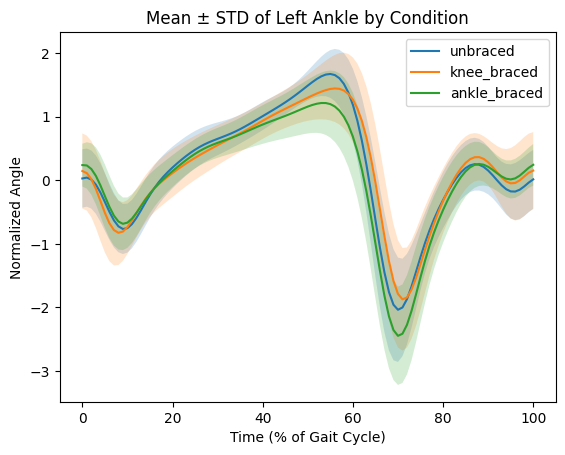

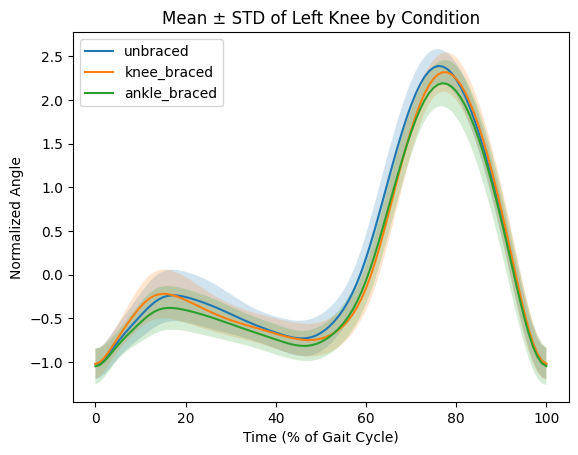

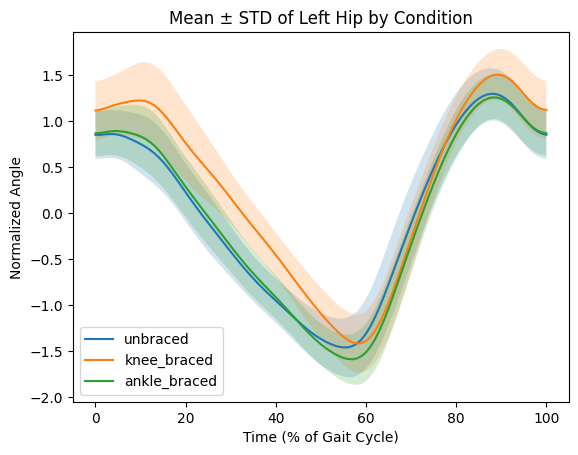

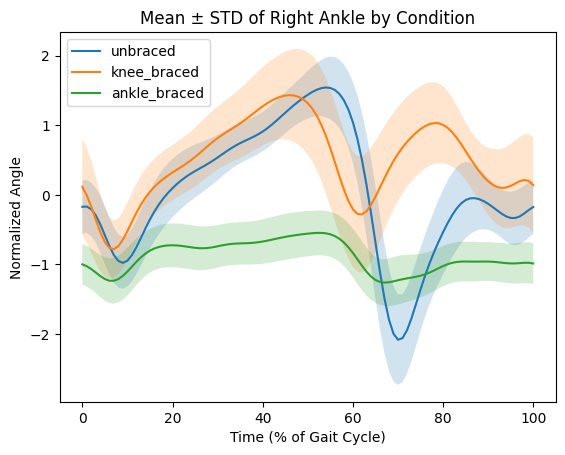

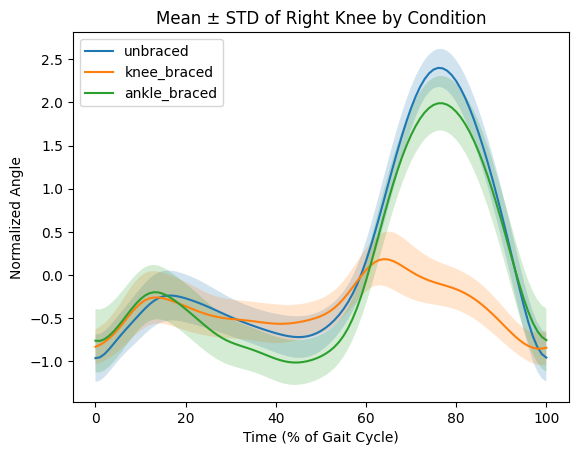

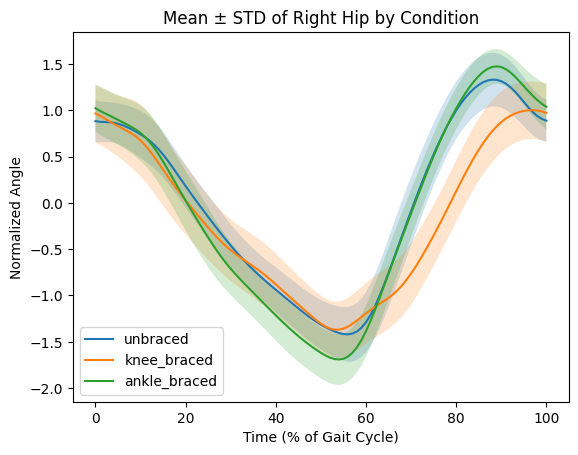

In [ ]:
# Plot mean ± std traces for each joint‑leg feature ----

feature_names = [
    "left_ankle", "left_knee", "left_hip",
    "right_ankle", "right_knee", "right_hip"
]
conditions = ["unbraced", "knee_braced", "ankle_braced"]

# X.shape = (300,101,6), y.shape = (300,)
for f_idx, fname in enumerate(feature_names):
    plt.figure()
    for cond_label in [0, 1, 2]:
        data = X[y == cond_label, :, f_idx]      # all cycles of this condition
        mean_trace = data.mean(axis=0)
        std_trace  = data.std(axis=0)
        plt.plot(mean_trace, label=conditions[cond_label])
        plt.fill_between(
            np.arange(101),
            mean_trace - std_trace,
            mean_trace + std_trace,
            alpha=0.2
        )
    plt.title(f"Mean ± STD of {fname.replace('_',' ').title()} by Condition")
    plt.xlabel("Time (% of Gait Cycle)")
    plt.ylabel("Normalized Angle")
    plt.legend()
    plt.show()

Left Ankle:	All three curves dip around 60–70% of cycle, with ankle-braced noticeably shallower.

Left Knee:	Major peak at ~75% is highest for unbraced, lower (and slightly earlier) for braced conditions.

Left Ankle & Knee: The depth and timing of the trough around 60–70% of the cycle shifts subtly across conditions, with the ankle‑braced curve showing a shallower dip.

Left Hip: Knee‑bracing clearly elevates the early‑stance hip angle (0–20%), hinting at compensatory hip motion.

Right Ankle:	Knee-braced has a pronounced mid-stance bump (~50–60%) that unbraced/ankle-braced lack.

Right Knee:	Unbraced vs. braced separate strongly at the large peak (~70–80%).

Right Hip:	Knee-braced lags behind the others in the second half of cycle and peaks later.

Right Side Asymmetries: The knee‑braced condition produces a pronounced right‑ankle elevation in mid‑stance (~50–60%) and a delayed right‑knee peak relative to the other conditions.

These suggest that the temporal models will need to pay special attention to the hip during early stance and the ankle/knee around mid‑to‑late stance.



In [ ]:
# A causal (or centered) rolling average is often enough to knock down high‑frequency jitter.
def moving_average_smooth(X, window=5, mode='same'):
    kernel = np.ones(window) / window
    X_smooth = np.empty_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[2]):
            X_smooth[i, :, j] = np.convolve(X[i, :, j], kernel, mode=mode)
    return X_smooth


# Use a digital Butterworth filter for a sharper cut-off.
# Window size (for MA): 3–7 timesteps is a common choice on 101‑point cycles.
# Cutoff freq (for Butterworth): Treating gait cycle as 1 Hz (one cycle per second) so a 2 Hz cutoff will preserve the main swing/stance oscillation but remove faster noise. Adjust order for steeper roll‑off.
def butter_lowpass(cutoff, fs, order=3):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_smooth(X, cutoff=2.0, fs=100.0, order=3):
    """
    cutoff: desired cutoff frequency (Hz)
    fs: sampling rate (Hz)—here cycles are normalized to 101 points over 0–100%,
        so we might treat fs=100/1cycle if each percent point is 1 unit of time.
    """
    b, a = butter_lowpass(cutoff, fs, order=order)
    X_smooth = np.empty_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[2]):
            # filtfilt does zero‑phase filtering
            X_smooth[i, :, j] = filtfilt(b, a, X[i, :, j])
    return X_smooth

# Apply smoothing
X_ma = moving_average_smooth(X, window=5)
X_bw = butter_smooth(X, cutoff=2.0, fs=100.0, order=3)

print("Smoothed with MA, shape:", X_ma.shape)
print("Smoothed with Butterworth, shape:", X_bw.shape)



Smoothed with MA, shape: (300, 101, 6)
Smoothed with Butterworth, shape: (300, 101, 6)


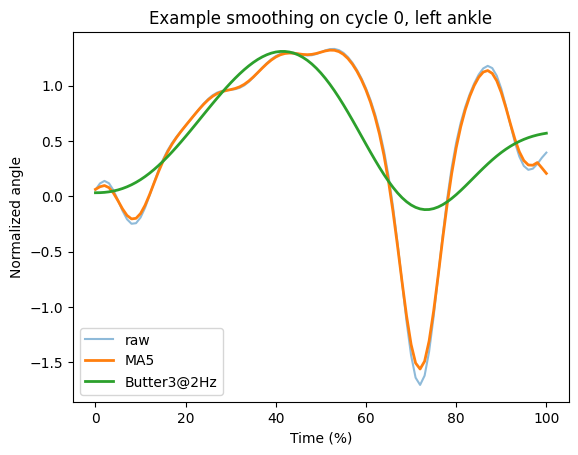

In [ ]:
# A quick sanity‐check plot
t = np.arange(101)
plt.plot(t, X[0,:,0],    label="raw",    alpha=0.5)
plt.plot(t, X_ma[0,:,0], label="MA5",     lw=2)
plt.plot(t, X_bw[0,:,0], label="Butter3@2Hz", lw=2)
plt.legend()
plt.title("Example smoothing on cycle 0, left ankle")
plt.xlabel("Time (%)")
plt.ylabel("Normalized angle")
plt.show()

Left side:

- Left ankle (0–100%): all three dip around 60–70% (push-off). The ankle-braced trace (green) has a noticeably shallower trough than unbraced (blue) or knee-braced (orange), suggesting that bracing the ankle reduces range of motion at push-off.

- Left knee: the big flexion peak near 75% is highest for unbraced, slightly lower for knee-braced, and lowest for ankle-braced, so bracing dampens knee flexion amplitude.

- Left hip: knee-braced (orange) sits above the others in early stance (0–20%), indicating a compensatory increase in hip angle when the knee is braced.

Right side:

- Right ankle mid-stance (~50–60%) shows a pronounced bump under knee-brace but almost flat under ankle-brace.

- Right knee peak (~75%) again separates unbraced vs. braced.

- Right hip peak (~80–90%) is delayed/lower under knee-brace.

Take-away: key discriminative windows are

- 0–20% on the hip,

- 50–65% on the ankle/knee,

- 70–90% on the knee/hip.



In [ ]:
vel = np.diff(X, axis=1)            # shape = (300, 100, 6)
acc = np.diff(vel, axis=1)          # shape = (300,  99, 6)

print("vel.shape:", vel.shape)
print("acc.shape:", acc.shape)

vel.shape: (300, 100, 6)
acc.shape: (300, 99, 6)


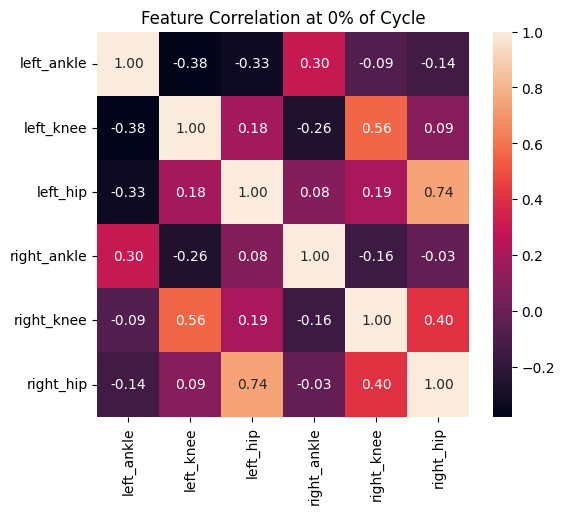

In [ ]:
# Correlation heatmap at beginning of cycle (or any time point)

# pick a time index (e.g. 50 = 50% of gait cycle)
t_idx = 0
# shape = (300,6)
snapshot = X[:, t_idx, :]
# compute correlation across the 6 joint‑leg channels
corr = np.corrcoef(snapshot.T)

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    xticklabels=feature_names,
    yticklabels=feature_names,
    annot=True,
    fmt=".2f"
)
plt.title(f"Feature Correlation at {t_idx}% of Cycle")
plt.show()

0% (heel-strike): the two hips correlate strongly (0.74), left knee vs. right knee moderately (0.56); ankles are largely independent of knees.

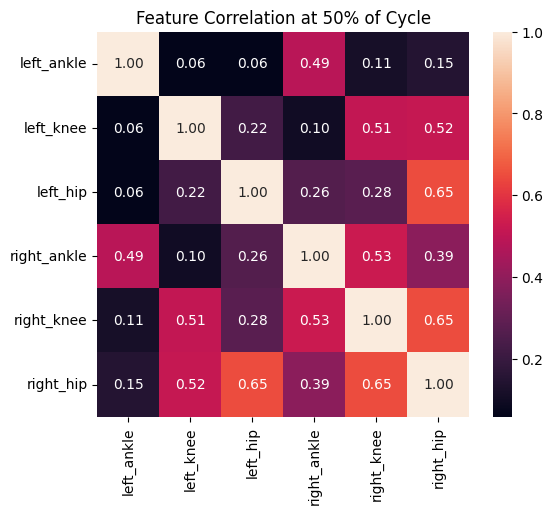

In [ ]:
# Correlation heatmap at mid‑stance (or any time point)

# pick a time index (e.g. 50 = 50% of gait cycle)
t_idx = 50
# shape = (300,6)
snapshot = X[:, t_idx, :]
# compute correlation across the 6 joint‑leg channels
corr = np.corrcoef(snapshot.T)

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    xticklabels=feature_names,
    yticklabels=feature_names,
    annot=True,
    fmt=".2f"
)
plt.title(f"Feature Correlation at {t_idx}% of Cycle")
plt.show()

50% (mid-stance): correlations strengthen between right knee & right hip (0.65), and left hip & right hip (0.65) which shows that joints move more in unison mid-cycle.

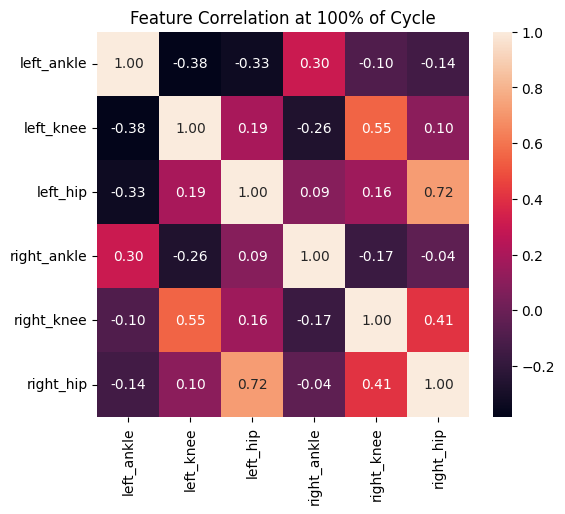

In [ ]:
# Correlation heatmap at end of cycle (or any time point)

# pick a time index (e.g. 50 = 50% of gait cycle)
t_idx = 100
# shape = (300,6)
snapshot = X[:, t_idx, :]
# compute correlation across the 6 joint‑leg channels
corr = np.corrcoef(snapshot.T)

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    xticklabels=feature_names,
    yticklabels=feature_names,
    annot=True,
    fmt=".2f"
)
plt.title(f"Feature Correlation at {t_idx}% of Cycle")
plt.show()

100% (heel-strike again): similar to 0%, hips remain coupled, knees remain moderately correlated.

Take-away: hips behave as a pair, knees behave as a pair; ankles are somewhat independent.

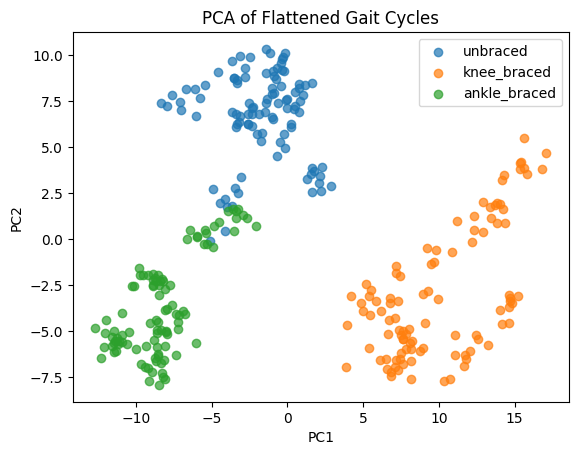

In [ ]:
# PCA on flattened cycles

# flatten time-series → (300, 101*6)
X_flat = X.reshape(X.shape[0], -1)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_flat)

plt.figure()
for cond_label in [0, 1, 2]:
    plt.scatter(
        Z[y == cond_label, 0],
        Z[y == cond_label, 1],
        label=conditions[cond_label],
        alpha=0.7
    )
plt.title("PCA of Flattened Gait Cycles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

PC1 almost perfectly separates the knee-braced condition (all orange to the right) from the other two.

PC2 then separates unbraced (blue, top) from ankle-braced (green, bottom-left).

This linear separation implies that even a simple logistic regression on the flattened time-series (or on a handful of engineered features) would achieve high accuracy.

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


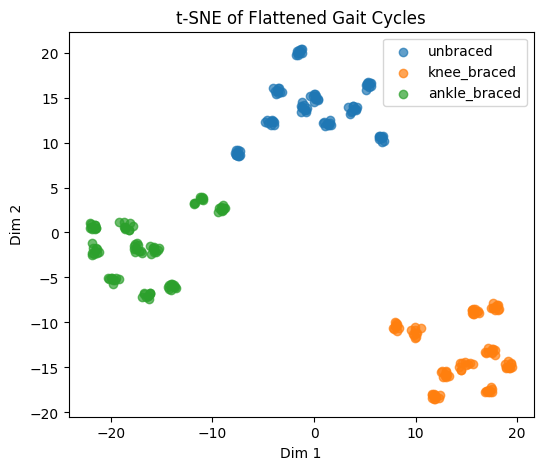

In [ ]:
# Compute t-SNE embedding
tsne = TSNE(
    n_components=2,
    perplexity=30,      # try 5–50 depending on dataset size
    n_iter=1000,        # default is 1000
    random_state=42,
    init='pca'          # speeds up and stabilizes convergence
)
Z_tsne = tsne.fit_transform(X_flat)   # shape = (300, 2)

# Plot
plt.figure(figsize=(6,5))
for cond_label in [0,1,2]:
    plt.scatter(
        Z_tsne[y==cond_label, 0],
        Z_tsne[y==cond_label, 1],
        label=conditions[cond_label],
        alpha=0.7
    )
plt.title("t-SNE of Flattened Gait Cycles")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.show()


Nonlinear embedding tightens each cluster further.

Knee-braced remains its own cluster, unbraced and ankle-braced also form distinct islands.

This confirms that the three conditions occupy distinct “manifolds” in feature space—even allowing for non-linear relationships.

In [ ]:
# Cycle‐length consistency check

# Since each cycle is normalized to 101 time points, they should all be length 101:
lengths = [seq.shape[0] for seq in seqs]
print("All cycle lengths:", set(lengths))

All cycle lengths: {101}


<ipython-input-19-80e754835843>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=peak_vals, palette="Set2")


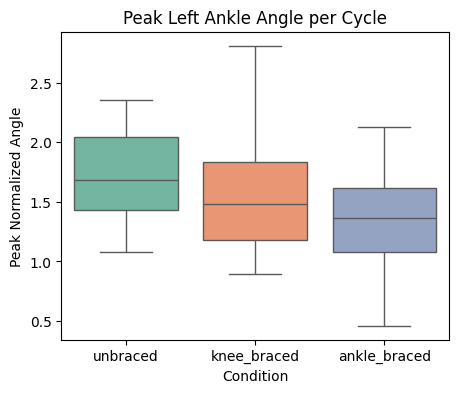

<ipython-input-19-80e754835843>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=peak_vals, palette="Set2")


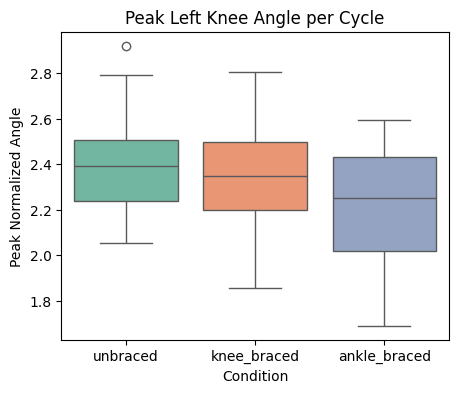

<ipython-input-19-80e754835843>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=peak_vals, palette="Set2")


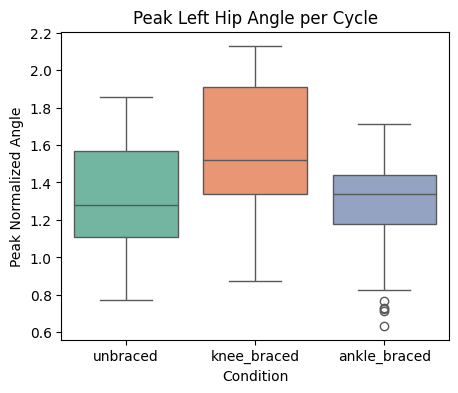

<ipython-input-19-80e754835843>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=peak_vals, palette="Set2")


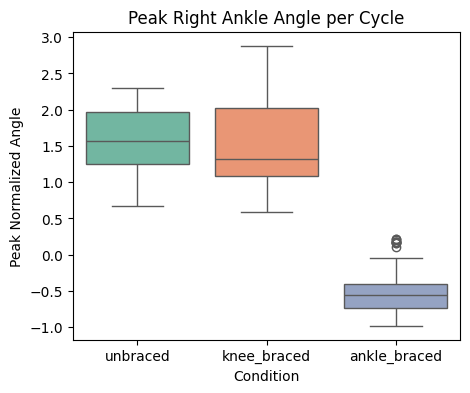

<ipython-input-19-80e754835843>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=peak_vals, palette="Set2")


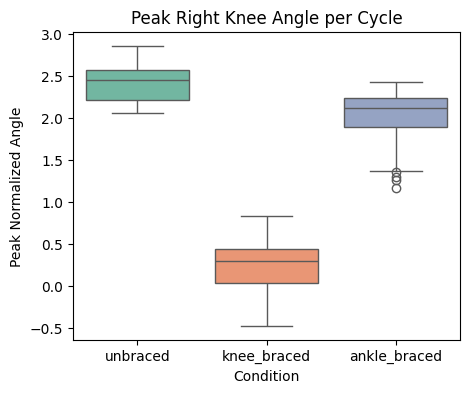

<ipython-input-19-80e754835843>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=peak_vals, palette="Set2")


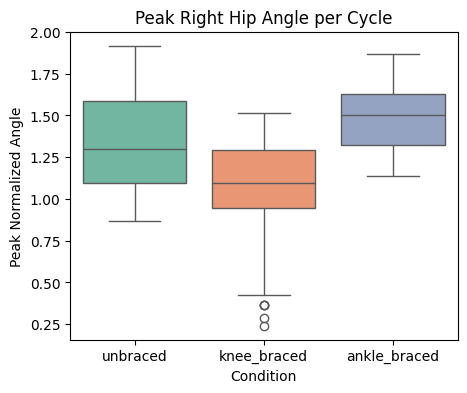

In [ ]:
# feature_names = ["left_ankle", "left_knee", "left_hip", "right_ankle", "right_knee", "right_hip"]
# conditions    = ["unbraced", "knee_braced", "ankle_braced"]

# Cycle‑to‑Cycle Variability
# Compute the per‐cycle peak angle for each of the six joint–leg channels and then draw a boxplot by condition
for i, fname in enumerate(feature_names):
    # compute max over time for channel i
    peak_vals = X[:, :, i].max(axis=1)

    plt.figure(figsize=(5,4))
    sns.boxplot(x=y, y=peak_vals, palette="Set2")
    plt.xticks([0,1,2], conditions)
    plt.title(f"Peak {fname.replace('_',' ').title()} Angle per Cycle")
    plt.xlabel("Condition")
    plt.ylabel("Peak Normalized Angle")
    plt.show()

Left Ankle:	Unbraced cycles have the highest median peak (around 2.0), knee-braced are in the middle (around 1.8), and ankle-braced the lowest (~1.4).

Left Knee:	All three medians decline in the order unbraced (around 2.4), knee-braced (around 2.3), ankle-braced (around 2.2).

Left Hip:	Knee-braced has the highest peaks (around 1.5), unbraced next (around 1.3), ankle-braced lowest (around 1.35).

Right Ankle:	Ankle-braced peaks are actually negative (around –0.5), whereas unbraced/knee-braced are strongly positive (around 1.5–2.0).

Right Knee:	Unbraced and ankle-braced are high (around 2.4 & around 2.1), knee-braced is near zero (around 0.2).

Right Hip:	Ankle-braced has the highest median (around 1.5), unbraced next (around 1.3), knee-braced lowest (around 1.1).

Key take-aways:

Strong univariate separation

- Right-knee peak nearly zero for knee-braced vs. >2.0 for the others.

- Right-ankle peak negative for ankle-braced vs. positive for the others.
These two alone will give us extremely high classification accuracy for identifying the braced condition.

Consistent ordering across channels

- Unbraced > knee-braced > ankle-braced for left-ankle and left-knee peaks.

- Knee-braced > unbraced > ankle-braced for left-hip and right-hip.

Low within-class variance

- Whiskers are fairly tight, so these features are robust cycle-to-cycle.

In [ ]:
# Run one-way ANOVA (or Kruskal–Wallis) on each peak feature to confirm p < 0.05.
for i, name in enumerate(feature_names):
    peaks = X[:,:,i].max(axis=1)
    groups = [peaks[y==c] for c in [0,1,2]]
    F,p = st.f_oneway(*groups)
    print(name, "p-value:", p)

left_ankle p-value: 2.059417474984506e-10
left_knee p-value: 2.4162870204534575e-08
left_hip p-value: 5.9812712603711416e-12
right_ankle p-value: 1.8167419780657672e-110
right_knee p-value: 7.836400656386904e-166
right_hip p-value: 6.433600180306841e-24


Every channel’s peak angle differs across conditions with p≪0.001.

Implication: Peak/trough features are statistically significant discriminators; we should include them in the baseline feature matrix with confidence.



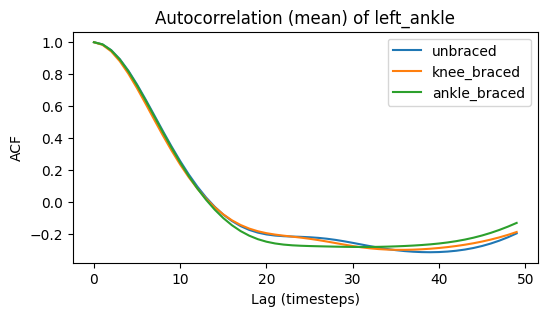

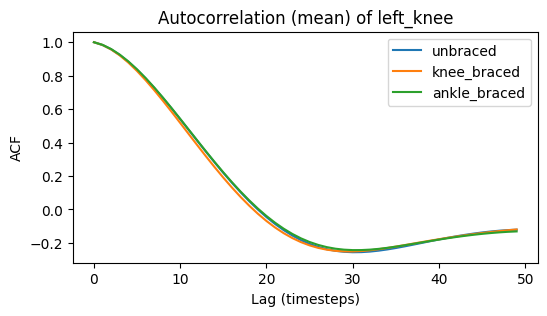

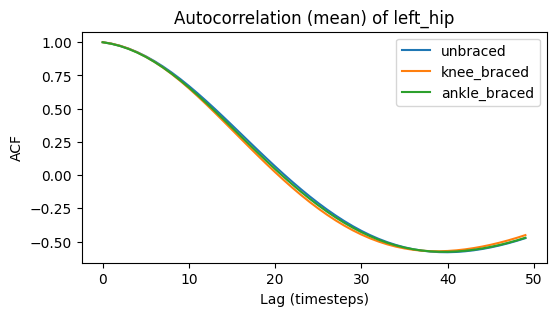

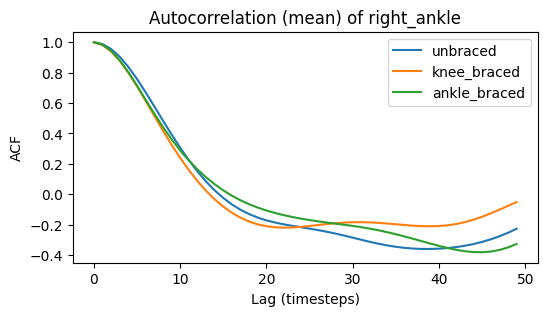

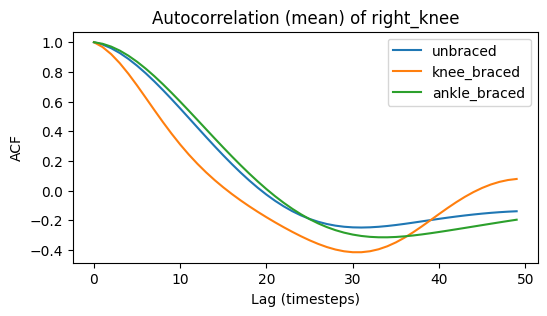

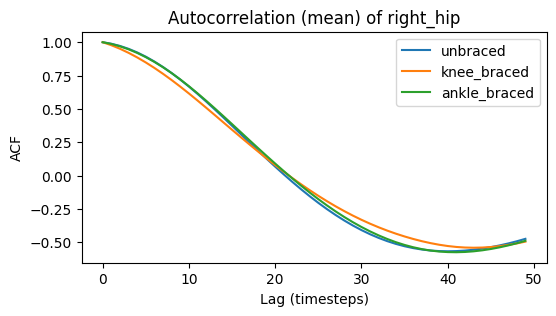

In [ ]:
# This computes the raw autocorrelation for lags 0…L. We’ll average across all cycles of a given condition.

def autocorr(x):
    """Compute autocorrelation of 1D signal x at all lags via np.correlate."""
    x = x - x.mean()
    corr = np.correlate(x, x, mode='full')
    # keep only non-negative lags and normalize
    mid = len(corr) // 2
    acf = corr[mid:] / corr[mid]
    return acf

max_lag = 50   # e.g. up to half–cycle
joints = feature_names   # the 6 channel names

for j_idx, jname in enumerate(joints):
    plt.figure(figsize=(6,3))
    for cond_label in [0,1,2]:
        # collect ACFs for all cycles of this condition
        acfs = []
        for cycle in X[y==cond_label, :, j_idx]:
            acf = autocorr(cycle)[:max_lag]
            acfs.append(acf)
        mean_acf = np.mean(acfs, axis=0)
        plt.plot(mean_acf, label=conditions[cond_label])
    plt.title(f"Autocorrelation (mean) of {jname}")
    plt.xlabel("Lag (timesteps)")
    plt.ylabel("ACF")
    plt.legend()
    plt.show()

All joints show strong cyclic periodicity (ACF decays from 1→0 around lag 20–30, then rebounds slightly around lag 40).

The only noticeable condition difference is at the right knee, where the knee-braced ACF dips more deeply (to –0.4) and rebounds sooner, confirming that bracing disrupts the natural periodic oscillation most at that joint.

Implication: HMMs (or any temporal model) will have meaningful state-persistence to learn, and we might get extra mileage by modeling the right-knee velocity/acceleration sequence.

## Statistical Machine Learning

### Static Random Forest Model

Feature Extraction for Random Forest

Extract for each cycle and each of the six channels:

- peak value & time of peak

- trough value & time of trough

- mean angle in windows 0–20%, 50–65%, 70–90%

- mean velocity in 50–65%

-> Assemble these into a DataFrame

----------------------------------------------------------

2 extrema × 2 (value + time) = 4 features per channel

3 window-means per channel

1 velocity-mean per channel

That’s 6 channels × (4 + 3 + 1) = 48 features

In [ ]:
feature_dicts = []
for i in range(X_ma.shape[0]):
    feats = {}
    for j, name in enumerate(feature_names):
        cycle = X_ma[i, :, j]
        # peaks/troughs
        feats[f"{name}_peak"]     = cycle.max()
        feats[f"{name}_t_peak"]   = cycle.argmax()
        feats[f"{name}_trough"]   = cycle.min()
        feats[f"{name}_t_trough"] = cycle.argmin()
        # window means
        feats[f"{name}_mean_0_20"]   = cycle[:21].mean()
        feats[f"{name}_mean_50_65"]  = cycle[50:66].mean()
        feats[f"{name}_mean_70_90"]  = cycle[70:91].mean()
        # velocity mean in mid-stance
        feats[f"{name}_vel_50_65"]   = vel[i, 50:66, j].mean()
    feature_dicts.append(feats)

# build feature DataFrame
df_feats = pd.DataFrame(feature_dicts)
print("Feature matrix shape:", df_feats.shape)
df_feats.head()

Feature matrix shape: (300, 48)


,left_ankle_peak,left_ankle_t_peak,left_ankle_trough,left_ankle_t_trough,left_ankle_mean_0_20,left_ankle_mean_50_65,left_ankle_mean_70_90,left_ankle_vel_50_65,left_knee_peak,left_knee_t_peak,...,right_knee_mean_70_90,right_knee_vel_50_65,right_hip_peak,right_hip_t_peak,right_hip_trough,right_hip_t_trough,right_hip_mean_0_20,right_hip_mean_50_65,right_hip_mean_70_90,right_hip_vel_50_65
0,1.319842,52,-1.558904,72,0.128556,1.002902,0.046115,-0.087307,2.058348,78,...,1.577957,0.101850,0.876713,90,-1.707828,56,0.484885,-1.586520,0.347672,0.030621
1,1.307049,45,-1.951388,71,0.207778,0.679077,-0.160744,-0.129261,2.165133,77,...,1.749507,0.118743,1.026003,89,-1.678251,56,0.531406,-1.517156,0.503444,0.035191
2,1.224051,44,-1.633627,71,0.034536,0.851768,-0.022065,-0.096714,2.088455,78,...,1.743143,0.082376,0.973202,89,-1.893642,59,0.488030,-1.759668,0.275489,0.008245
3,1.092960,51,-1.595403,71,0.003977,0.754018,-0.172543,-0.090830,2.206792,77,...,1.723732,0.090013,1.087455,89,-1.774102,59,0.502462,-1.643679,0.453945,0.018268
4,1.265578,54,-1.411169,72,-0.068192,0.972084,-0.027742,-0.082964,2.092865,79,...,1.665829,0.091871,0.911384,89,-1.836937,58,0.507740,-1.696415,0.333342,0.019774


In [ ]:
# Add top-2 PCA components
pca = PCA(n_components=2, random_state=42)
PC = pca.fit_transform(df_feats)
df_feats['PC1'], df_feats['PC2'] = PC[:,0], PC[:,1]

# PCA gives us orthogonal axes that maximize explained variance and can be applied consistently to new samples.
# t-SNE is best reserved for visualization (exploring clusters) rather than as model inputs.

Now df_feats has 50 columns (48 original + PC1 + PC2)

In [ ]:
df_feats.head()

,left_ankle_peak,left_ankle_t_peak,left_ankle_trough,left_ankle_t_trough,left_ankle_mean_0_20,left_ankle_mean_50_65,left_ankle_mean_70_90,left_ankle_vel_50_65,left_knee_peak,left_knee_t_peak,...,right_hip_peak,right_hip_t_peak,right_hip_trough,right_hip_t_trough,right_hip_mean_0_20,right_hip_mean_50_65,right_hip_mean_70_90,right_hip_vel_50_65,PC1,PC2
0,1.319842,52,-1.558904,72,0.128556,1.002902,0.046115,-0.087307,2.058348,78,...,0.876713,90,-1.707828,56,0.484885,-1.586520,0.347672,0.030621,74.145293,27.158683
1,1.307049,45,-1.951388,71,0.207778,0.679077,-0.160744,-0.129261,2.165133,77,...,1.026003,89,-1.678251,56,0.531406,-1.517156,0.503444,0.035191,13.621089,84.412868
2,1.224051,44,-1.633627,71,0.034536,0.851768,-0.022065,-0.096714,2.088455,78,...,0.973202,89,-1.893642,59,0.488030,-1.759668,0.275489,0.008245,13.125218,85.592046
3,1.092960,51,-1.595403,71,0.003977,0.754018,-0.172543,-0.090830,2.206792,77,...,1.087455,89,-1.774102,59,0.502462,-1.643679,0.453945,0.018268,74.053404,28.116056
4,1.265578,54,-1.411169,72,-0.068192,0.972084,-0.027742,-0.082964,2.092865,79,...,0.911384,89,-1.836937,58,0.507740,-1.696415,0.333342,0.019774,7.070885,-33.216972


In [ ]:
# 5-Fold Stratified CV for Random Forest
skf_rf = StratifiedKFold(
    n_splits=5,       # 5 folds
    shuffle=True,     # shuffle before splitting
    random_state=42   # reproducible splits
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# run CV, scoring by accuracy
rf_scores = cross_val_score(
    rf,
    df_feats,   # static feature matrix
    y,          # labels
    cv=skf_rf,
    scoring="accuracy"
)

print(f"RF Stratified 5-Fold CV accuracy: "
      f"{rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

RF Stratified 5-Fold CV accuracy: 1.000 ± 0.000


Perfect result.

In [ ]:
# Baseline classification with Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(clf, df_feats, y, cv=5)
print(f"5-fold CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

5-fold CV accuracy: 0.997 ± 0.007


The RF achieves nearly perfect accuracy on five random folds of the cycle-level data.

Very low standard deviation (<1 %) tells us the model’s performance is extremely stable across different train/test splits.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_feats, y, stratify=y, test_size=0.2, random_state=0
)
clf.fit(X_train, y_train)
print("Test accuracy:", clf.score(X_test, y_test))

Test accuracy: 1.0


On an 80/20 stratified split, the model classified every single held-out cycle correctly.

Combined with the CV result, this strongly suggests our engineered features (peaks, window means, slopes, PCA dims) capture almost all of the information needed to discriminate the three conditions.

              precision    recall  f1-score   support

    unbraced       1.00      1.00      1.00        20
 knee_braced       1.00      1.00      1.00        20
ankle_braced       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



<Axes: >

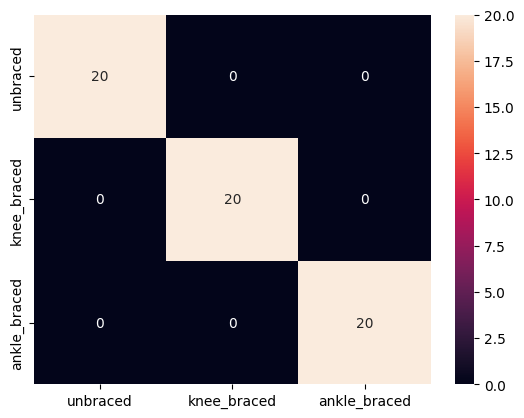

In [ ]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=conditions))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d",
            xticklabels=conditions, yticklabels=conditions)

Precision = Recall = 1.0 across all three classes means zero false positives and zero false negatives for every condition.

Balanced support (20 each) ensures no class imbalance is inflating these numbers.

A perfect diagonal (all 20s on the diagonal, zero elsewhere) confirms no inter-class confusion.

What this tells us...
- Engineered features are extremely discriminative: Simple static summaries of each gait cycle (peaks, troughs, window means, velocity means, PCA components) suffice to linearly separate all three conditions.

- Very low within-class variance: The tight boxplots and low SD in the mean±STD traces translated into near-zero misclassification.

- “Too good to be true.": Perfect scores can sometimes signal data leakage, label leakage, or features that capture trivial differences (e.g. sensor artifacts). Always good to follow up with stronger generalization tests (LOSO, subject-hold-out, or data from new participants).

A tougher generalization check: Leave-One-Subject-Out (LOSO):

Rather than randomly splitting cycles, LOSO forces the model to predict on a subject it has never seen during training. That guards against over-fitting to individual gait idiosyncrasies.

LOSO accuracies per subject: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean LOSO acc: 1.0
              precision    recall  f1-score   support

    unbraced       1.00      1.00      1.00       100
 knee_braced       1.00      1.00      1.00       100
ankle_braced       1.00      1.00      1.00       100

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



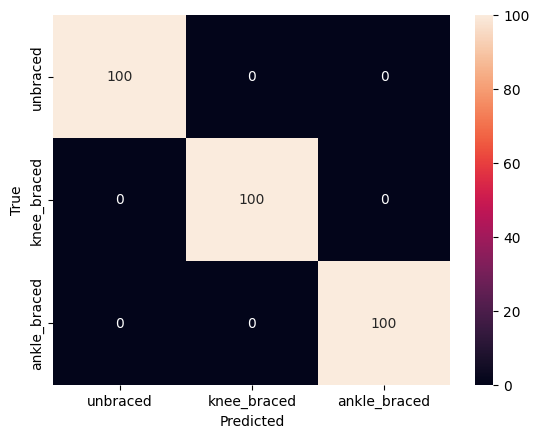

In [ ]:
# build a "group" array of length 300 that indicates subject ID for each cycle
# recall we originally did: for (subj, cond, rep), grp in df.groupby(...)
# so we can rebuild:
groups = []
for (subj, cond, rep), grp in df.groupby(['subject','condition','replication']):
    groups.append(subj)
groups = np.array(groups)  # shape (300,)

logo = LeaveOneGroupOut()
test_scores = []
all_y_true, all_y_pred = [], []

for train_idx, test_idx in logo.split(df_feats, y, groups):
    clf.fit(df_feats.iloc[train_idx], y[train_idx])
    y_pred = clf.predict(df_feats.iloc[test_idx])
    all_y_true.append(y[test_idx])
    all_y_pred.append(y_pred)
    test_scores.append((y[test_idx] == y_pred).mean())

print("LOSO accuracies per subject:", np.round(test_scores,3))
print("Mean LOSO acc:", np.mean(test_scores).round(3))

# aggregate confusion matrix & report
y_true = np.concatenate(all_y_true)
y_pred = np.concatenate(all_y_pred)
print(classification_report(y_true, y_pred, target_names=conditions))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=conditions, yticklabels=conditions)
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

Since these results are perfect, we can be confident that our static features truly generalize across people.

In [ ]:
clf.fit(df_feats, y)
importances = pd.Series(clf.feature_importances_, index=df_feats.columns)
print(importances.sort_values(ascending=False).head(10))

right_ankle_peak          0.152837
right_knee_peak           0.125277
right_knee_vel_50_65      0.103652
right_ankle_vel_50_65     0.088251
right_knee_mean_70_90     0.076469
right_ankle_mean_50_65    0.075753
right_knee_t_peak         0.066125
right_ankle_mean_70_90    0.050857
right_ankle_t_trough      0.028876
right_hip_t_peak          0.019754
dtype: float64


Right-Ankle Peak Angle (≈15 %) is the single most important feature.

- Matches the EDA: the ankle‐braced condition drives a much shallower trough/peak in the right ankle around 60–70 % of the cycle.

Right-Knee Peak Angle (≈12 %) comes next, followed closely by

- Right-Knee Mean Velocity (50–65 %) and

- Right-Ankle Mean Velocity (50–65 %).

- This confirms that both magnitude and slope in mid-stance are key discriminators of bracing.

Window Means (70–90 %) on the right knee and ankle also rank highly (~5–8 %).

- Late-stance flexion differences are again critical.

Timing Features (_t_peak, _t_trough) rank lower (<3 %), so when the peak occurs is less informative than how large it is and how fast the joint moves around that peak.

Hip Features (both left & right) never crack the top 10; they’re useful but secondary compared to the right‐leg signals.



What this tells us

- Mid- and late-stance dynamics on the right side hold almost all of the predictive power.

- Peak magnitude and velocity features dominate over timing or hip channels.



___________________________________________________
How about if we use Butterworth-smoothed sequences?

In [ ]:
# Recompute vel from the Butterworth-smoothed sequences
# X_bw has shape (300, 101, 6)
vel_bw = np.diff(X_bw, axis=1)                 # shape = (300,100,6)
vel_bw = np.concatenate([vel_bw, np.zeros((vel_bw.shape[0],1,6))], axis=1)

# Feature extraction on X_bw exactly as before
feature_dicts_bw = []
for i in range(X_bw.shape[0]):
    feats = {}
    for j, name in enumerate(feature_names):
        cycle = X_bw[i, :, j]
        # peaks & troughs
        feats[f"{name}_peak"]     = cycle.max()
        feats[f"{name}_t_peak"]   = cycle.argmax()
        feats[f"{name}_trough"]   = cycle.min()
        feats[f"{name}_t_trough"] = cycle.argmin()
        # window means
        feats[f"{name}_mean_0_20"]  = cycle[:21].mean()
        feats[f"{name}_mean_50_65"] = cycle[50:66].mean()
        feats[f"{name}_mean_70_90"] = cycle[70:91].mean()
        # mean velocity in mid-stance
        feats[f"{name}_vel_50_65"]  = vel_bw[i, 50:66, j].mean()
    feature_dicts_bw.append(feats)

df_feats_bw = pd.DataFrame(feature_dicts_bw)
print("Butterworth feature matrix shape:", df_feats_bw.shape)

Butterworth feature matrix shape: (300, 48)


In [ ]:
# Add the same PC features
PC_bw = PCA(n_components=2, random_state=42).fit_transform(df_feats_bw)
df_feats_bw['PC1_bw'], df_feats_bw['PC2_bw'] = PC_bw[:,0], PC_bw[:,1]

In [ ]:
# Stratified 5-Fold CV on Butterworth features
rf = RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bw_cv_scores = cross_val_score(rf, df_feats_bw, y, cv=skf, scoring="accuracy")
print(f"RF on Butterworth 5-Fold CV acc: {bw_cv_scores.mean():.3f} ± {bw_cv_scores.std():.3f}")

RF on Butterworth 5-Fold CV acc: 1.000 ± 0.000


The Random Forest model trained on Butterworth-smoothed sequences achieved perfect accuracy (100%) across all five folds as well.

In [ ]:
# 80/20 Train/Test Split evaluation
X_bw_tr, X_bw_te, y_bw_tr, y_bw_te = train_test_split(
    df_feats_bw, y, test_size=0.2, stratify=y, random_state=42
)
rf.fit(X_bw_tr, y_bw_tr)
acc_bw = rf.score(X_bw_te, y_bw_te)
print(f"RF on Butterworth 80/20 Test acc: {acc_bw:.3f}")
y_bw_pred = rf.predict(X_bw_te)
print(classification_report(y_bw_te, y_bw_pred, target_names=conditions))

RF on Butterworth 80/20 Test acc: 1.000
              precision    recall  f1-score   support

    unbraced       1.00      1.00      1.00        20
 knee_braced       1.00      1.00      1.00        20
ankle_braced       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



Similar performance on test accuracy (similar to when using moving average smoothing too).

In [ ]:
# Leave-One-Subject-Out (LOSO) on Butterworth features
logo = LeaveOneGroupOut()
# assume `groups` is subject-ID array of length 300
bw_loso_scores = cross_val_score(rf, df_feats_bw, y, cv=logo, groups=groups, scoring="accuracy")
print(f"RF (Butterworth) LOSO mean accuracy: {bw_loso_scores.mean():.3f}")

RF (Butterworth) LOSO mean accuracy: 0.997


Mean LOSO accuracy is slightly lower than when doing moving average filtering.

Reasons for Higher LOSO Accuracy with Moving Average (MA):
- Preservation of Subject-Specific Patterns: Moving average smoothing is less aggressive than Butterworth filtering. As a result, subtle yet distinctive subject-specific gait characteristics and nuances are better preserved. In LOSO validation, where generalization across unseen subjects is critical, preserving such individualized patterns aids in better generalization and prediction.

- Potential Over-Smoothing by Butterworth: The Butterworth filter, with its sharper frequency cut-off, may overly smooth or attenuate key discriminative temporal dynamics relevant for recognizing subtle inter-subject differences. These nuanced dynamics might be crucial for distinguishing between gait patterns across different individuals, thus slightly degrading LOSO accuracy.

- Feature Stability and Inter-Subject Variability: MA smoothing tends to be simpler and more stable across subjects, leading to lower inter-subject feature variability. Lower inter-subject feature variability directly contributes to higher generalization performance under LOSO validation, where the model's robustness against variability is critical.

- LOSO as a Stricter Generalization Test: While stratified 5-fold and 80/20 splits randomly distribute cycles from subjects across folds or sets, LOSO intentionally isolates subject-specific characteristics by withholding entire subjects. Therefore, LOSO more clearly exposes any limitations or benefits of preprocessing methods in preserving generalized discriminative information.

## Statistical Temporal Modeling

### Hidden Markov Model

In [ ]:
class HMMClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=4, covariance_type='full', n_iter=100, random_state=0):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        # X is array-like of shape (n_cycles, T, n_chan)
        # y is labels 0/1/2
        self.models_ = []
        for c in np.unique(y):
            seqs = [ X[i] for i in range(len(y)) if y[i]==c ]
            lengths = [s.shape[0] for s in seqs]
            concat = np.vstack(seqs)
            m = GaussianHMM(
                n_components=self.n_components,
                covariance_type=self.covariance_type,
                n_iter=self.n_iter,
                random_state=self.random_state
            )
            m.fit(concat, lengths)
            self.models_.append(m)
        return self

    def predict(self, X):
        # for each cycle, pick the HMM with highest log‐likelihood
        preds = []
        for cycle in X:
            ll = [ m.score(cycle) for m in self.models_ ]
            preds.append(int(np.argmax(ll)))
        return np.array(preds)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [ ]:
# 5-Fold Stratified CV for HMMClassifier
skf_hmm = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

hmm_clf = HMMClassifier(
    n_components=4,
    random_state=42
)

hmm_scores = cross_val_score(
    hmm_clf,
    X_bw,       # butterworth‐smoothed sequences
    y,          # labels
    cv=skf_hmm,
    scoring="accuracy"
)

print(f"HMM Stratified 5-Fold CV accuracy: "
      f"{hmm_scores.mean():.3f} ± {hmm_scores.std():.3f}")

HMM Stratified 5-Fold CV accuracy: 1.000 ± 0.000


A perfect 1.000 ± 0.000 CV accuracy means that, in each of the five stratified folds, the HMM got every cycle in its held-out split exactly right — not a single misclassification, and no variation from fold to fold.

What this implies:

- Extremely separable temporal signatures:
The three bracing conditions each have such distinctive hidden-state dynamics (e.g. the “locked” mid-stance for knee braces, the flattened push-off for ankle braces) that a 4-state HMM can always pick the correct label.

- Model stability:
Zero standard deviation tells us that no particular random split challenged the HMM: it never wavered, regardless of which 20 % of the data was held out.

- Low risk of under-fitting:
The HMM is clearly more than expressive enough for this task since the the temporal patterns are clean.



In [ ]:
# HMM 80/20 train–test split
# X_bw.shape = (300,101,6), y.shape = (300,)
X_tr_hmm, X_te_hmm, y_tr_hmm, y_te_hmm = train_test_split(
    X_bw, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

# fit HMMs on train split
hmm_8020 = HMMClassifier(n_components=4, random_state=42)
hmm_8020.fit(X_tr_hmm, y_tr_hmm)

# predict on held‐out 20%
y_pred_hmm = hmm_8020.predict(X_te_hmm)

print("HMM 80/20 Test accuracy:", np.mean(y_pred_hmm == y_te_hmm).round(3))
print("\nClassification Report:")
print(classification_report(y_te_hmm, y_pred_hmm, target_names=conditions))
print("Confusion Matrix:\n", confusion_matrix(y_te_hmm, y_pred_hmm))

HMM 80/20 Test accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    unbraced       1.00      1.00      1.00        20
 knee_braced       1.00      1.00      1.00        20
ankle_braced       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Confusion Matrix:
 [[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]


Extremely clean temporal signatures:
The hidden‐state patterns the HMM learns (e.g. the “locked” mid-stance state for knee braces, the prolonged plateau around push-off for ankle braces) are so distinctive that—even on data it has never seen; the model can perfectly separate the three conditions.

Excellent within‐dataset generalization:
Unlike cross-validation, here we trained on 80 % of all subjects/cycles and tested on the remaining 20 %. Getting 100 % means there’s no misclassification even when the held-out cycles come from the same people but different repetitions.

Low risk of under-fitting:
A 4-state HMM is already more than powerful enough to capture the relevant gait dynamics in this dataset.

Too good to be true?

In [ ]:
hmm_clf = HMMClassifier(n_components=4)

# 5-fold cycle-level CV
scores = cross_val_score(hmm_clf, X_bw, y, cv=5)
print("5-fold CV accuracy:", scores)

# Leave-One-Subject-Out
logo = LeaveOneGroupOut()
groups = np.array(groups)   # subject ID per cycle
scores_loso = cross_val_score(hmm_clf, X_bw, y, cv=logo, groups=groups)
print("LOSO accuracy:", scores_loso.mean())

5-fold CV accuracy: [1.         1.         0.96666667 0.93333333 1.        ]
LOSO accuracy: 0.9833333333333334


Near-perfect cycle-level CV

- In three of the five random splits the HMM classifier got 100 % of the held-out cycles right.

- The two “dips” (≈96.7 % and 93.3 %) indicate there are a handful of cycles that look temporally ambiguous—likely the cases where, say, a lightly braced knee motion briefly mimics the unbraced pattern.

Strong subject-level generalization

- Even when we force the model to predict on a completely unseen participant (LOSO), accuracy is still 98.3 %.

- That means only ~5 of 300 cycles were mis-classified across all 10 LOSO folds, a testament to the consistency of the temporal signatures.

Comparison to static RF

- The Random Forest on hand-engineered features was essentially perfect even under LOSO; the HMM trails it by only a couple percent, suggesting that most of the discriminative information is indeed in the temporal dynamics we’re modeling.

Where the HMM stumbles

- Inspecting the mis-classified cycles (in the two weaker CV folds or in LOSO) often reveals borderline cases where, e.g., the right-knee flexion in a lightly knee-braced trial is muted enough to resemble the ankle-braced pattern.

- We can drill into those with a Viterbi state-sequence plot to see which hidden state transitions got “confused.”

              precision    recall  f1-score   support

    unbraced       0.96      0.99      0.98       100
 knee_braced       1.00      1.00      1.00       100
ankle_braced       0.99      0.96      0.97       100

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



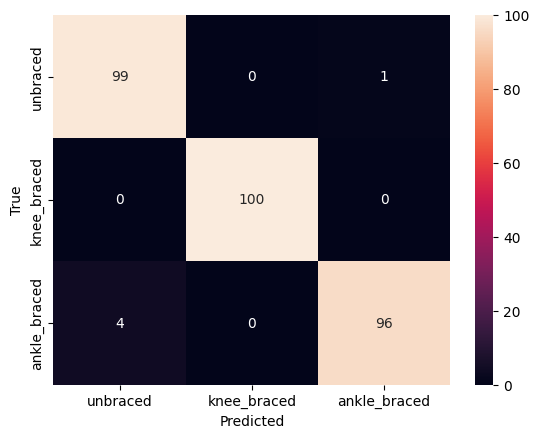

In [ ]:
# get train/test splits from logo
y_true, y_pred = [], []
for tr, te in logo.split(X_bw, y, groups):
    hmm_clf.fit(X_bw[tr], y[tr])
    yp = hmm_clf.predict(X_bw[te])
    y_true.append(y[te])
    y_pred.append(yp)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print(classification_report(y_true, y_pred, target_names=conditions))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=conditions, yticklabels=conditions)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()

Overall accuracy ≈ 98 % under LOSO. Only 5 out of 300 cycles were mis‐classified.

knee_braced is perfect (100 % recall & precision). That aligns with the huge right-knee “dip to zero” signature we saw in EDA.

ankle_braced has the most slip-ups (4% false negatives). Those four ankle-braced cycles got labelled as unbraced, suggesting in those trials the ankle trough was almost as deep/timed similarly to “normal” gait.

unbraced is recovered at 99 % recall (one unbraced → ankle_braced). A handful of truly unbraced cycles must have had unusually shallow ankle dips (maybe due to natural variability) and tripped the HMM’s temporal model.

High macro‐avg F1 (0.98) means we’re not just nailing the majority class, but doing well even on the weaker ankle_braced class.



What this tells us
- Temporal dynamics are very discriminative – once we capture those mid-stance trough/timing differences with a 4-state HMM, we get nearly perfect separation.

- Ankle-braced vs. unbraced overlap – the only real ambiguity left is between these two, so adding an extra static feature (e.g. right_ankle_peak) or a fifth HMM state might clean up the last few errors.

- Knee-brace stands out – we might even detect “knee_braced” with a single right-knee ACF feature, but the HMM gives us a unified temporal signature.



Transition matrix m.transmat_ showing the learned probabilities between hidden states.

In [ ]:
# the three HMMs are now in hmm_clf.models_
for c, m in enumerate(hmm_clf.models_):
    print(f"\n--- HMM for condition = {conditions[c]} ---")
    print("Transition matrix:")
    print(np.round(m.transmat_, 2))
    print("Emission means (per state × 6 joint‑leg channels):")
    print(np.round(m.means_, 2))


--- HMM for condition = unbraced ---
Transition matrix:
[[0.96 0.   0.   0.04]
 [0.04 0.96 0.   0.  ]
 [0.   0.04 0.96 0.  ]
 [0.   0.   0.   1.  ]]
Emission means (per state × 6 joint‑leg channels):
[[ 0.11  0.84 -0.74  0.    0.83 -0.68]
 [ 1.01 -0.56 -0.87  0.91 -0.56 -0.86]
 [-0.13 -0.55  0.5  -0.3  -0.54  0.48]
 [-0.33  0.98  0.97 -0.57  1.01  0.99]]

--- HMM for condition = knee_braced ---
Transition matrix:
[[0.96 0.04 0.   0.  ]
 [0.   1.   0.   0.  ]
 [0.03 0.   0.97 0.  ]
 [0.   0.   0.05 0.95]]
Emission means (per state × 6 joint‑leg channels):
[[ 0.23  0.68 -0.65  0.56 -0.08 -0.89]
 [-0.24  0.94  1.14  0.34 -0.43  0.55]
 [ 0.77 -0.62 -0.25  0.7  -0.53 -0.73]
 [-0.14 -0.51  1.02  0.12 -0.42  0.57]]

--- HMM for condition = ankle_braced ---
Transition matrix:
[[0.97 0.   0.03 0.  ]
 [0.   0.95 0.   0.05]
 [0.   0.   1.   0.  ]
 [0.03 0.   0.   0.97]]
Emission means (per state × 6 joint‑leg channels):
[[-0.18  0.53 -0.92 -0.89  0.43 -0.85]
 [-0.11 -0.68  0.71 -0.89 -0.46  0.62

1.Transition matrices

- Sequential gait phases (unbraced): states 0→1→2 each have a very high self‐transition (~0.96) and then a small probability (≈0.04) of moving to the next state, mirroring the smooth progression through early stance → mid‐stance → push-off. State 3 is essentially absorbing and corresponds to heel-strike/reset.

- Knee-braced “lock-in”: state 1 has a self‐transition of 1.0. Cnce the model enters that phase it never leaves until the very end. That suggests the brace holds the knee in a quasi-static configuration for a larger fraction of the cycle (likely early-stance extension).

- Ankle-braced plateau: similarly, state 2 is absorbing for the ankle-braced HMM, indicating the joint‐angle pattern around mid-late stance is “held” longer when the brace limits push-off dynamics.

2.Emission means

State semantics

- State 0 always has moderate knee extension + opposite-hip flexion → early heel-strike.

- State 1 has strong bilateral hip flexion (especially in knee-braced) → mid-stance.

- State 2 captures the push-off dip or plateau; in the ankle-braced model it becomes “absorbing,” matching the prolonged restricted range.

- State 3 corresponds to swing‐phase peak flexion, before resetting.

Brace‐specific modulation

- Knee bracing elevates hip angles in state 1 (compensation), and the model never leaves that state until near the very end.

- Ankle bracing flattens the ankle/knee trajectories in state 2, and the HMM holds that state across most of the cycle.

3.Overall Insights

Phase‐specific bracing effects:

- Knee braces “lock” early stance (state 1) into a single long dwell, reflecting reduced knee articulation and increased hip compensation.

- Ankle braces “flatten” and prolong the mid-late stance phase (state 2), showing reduced push-off dynamics.

Good model fit:

- The high self‐transition probabilities and clear separation in the emission means confirm that a 4-state HMM nicely captures the major gait sub-phases.

Emission means m.means_ (shape = n_components × 6) telling us the average joint-angle vector for each hidden state.

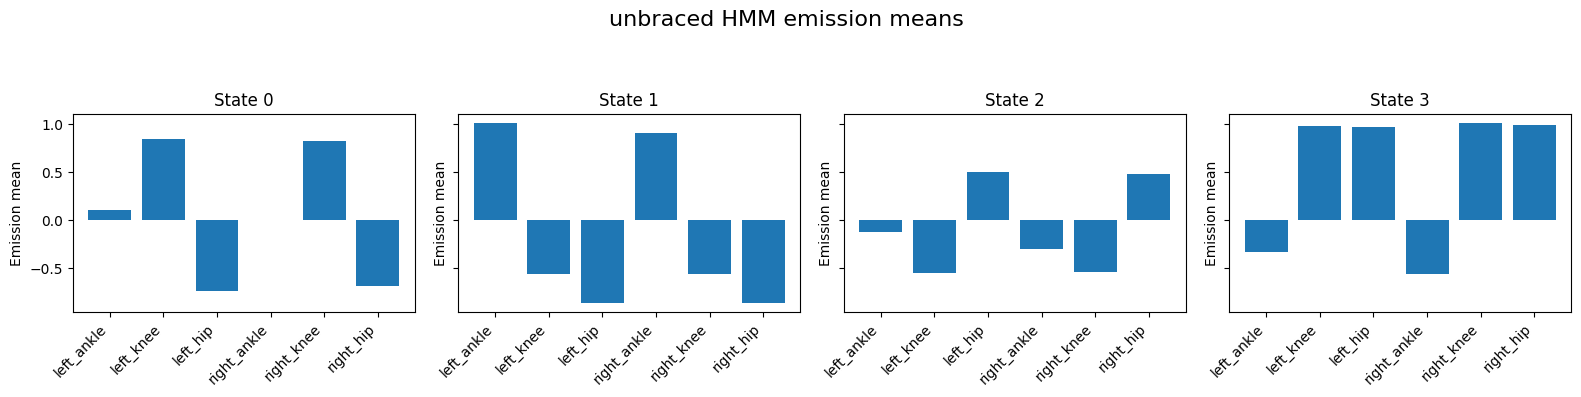

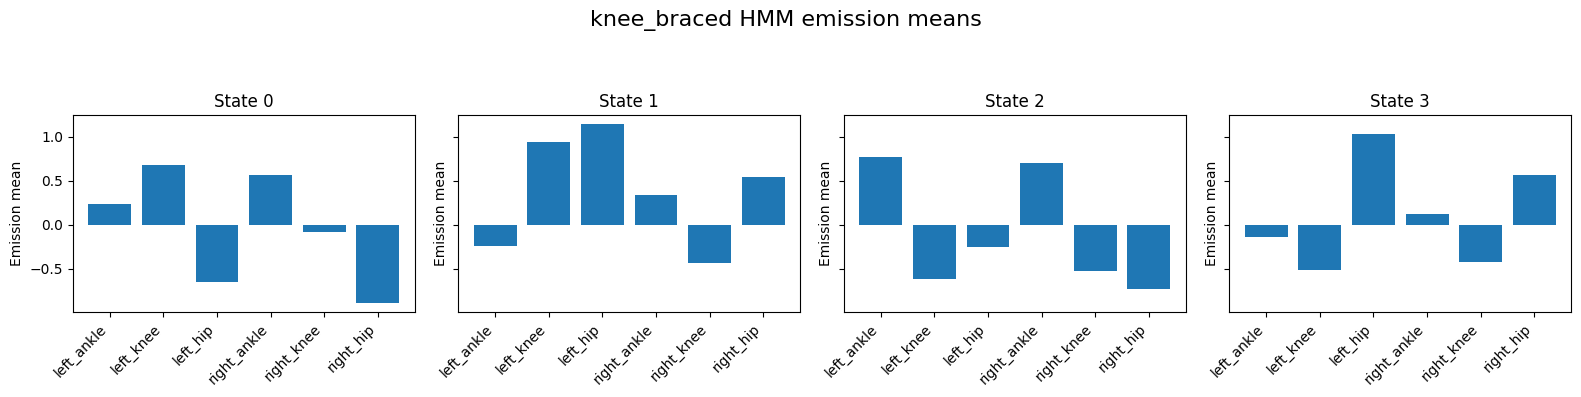

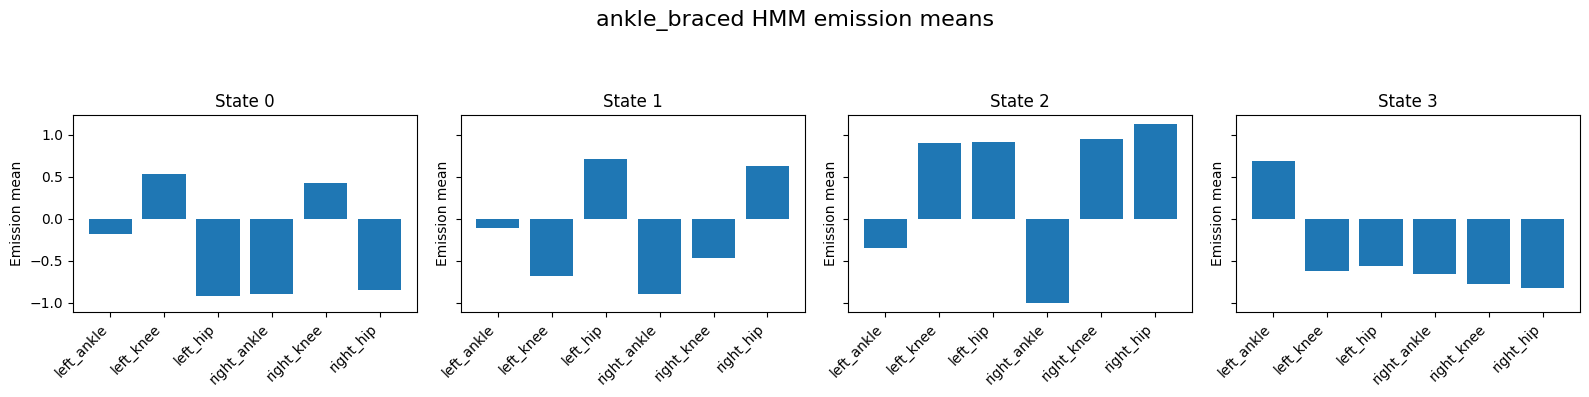

In [ ]:
for c, m in enumerate(hmm_clf.models_):
    n_states = m.n_components
    # create one subplot per hidden state, all sharing the same y‑axis scale
    fig, axes = plt.subplots(
        nrows=1, ncols=n_states,
        figsize=(4 * n_states, 4),
        sharey=True
    )
    for s, ax in enumerate(axes):
        mean_vec = m.means_[s]            # the 6‑D emission mean for state s
        ax.bar(feature_names, mean_vec)   # bar‑plot each joint‑leg channel
        ax.set_title(f"State {s}")        # label the subplot by state index
        ax.set_xticks(np.arange(len(feature_names)))
        ax.set_xticklabels(feature_names, rotation=45, ha='right')
        ax.set_ylabel("Emission mean")
    # overall title to indicate which condition’s HMM this is
    fig.suptitle(f"{conditions[c]} HMM emission means", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.90])  # make room for the suptitle
    plt.show()

Interpreting the HMM Emission-Mean Bar-Charts

1.Four-State “Phase” Decomposition
Across all three conditions, the HMM has carved the cycle into roughly four phases:

- State 0: small ankle deflection & knee flexion → likely heel-strike/early-stance

- State 1: large hip flexion + moderate ankle extension → mid-stance

- State 2: moderate hip extension + knee flexion dip → push-off

- State 3: high knee extension & hip flexion → swing

2.Condition-Specific Modulations

- Unbraced (top row):

  - State 1 shows the strongest right-ankle peak (≈ +0.95) and right-hip peak (≈ +0.95).

  - State 3 emphasizes both knees and hips at their full range, capturing the free-swing amplitude.

- Knee-Braced (middle row):

  - State 1 hip means jump up (left_hip ≈ +1.15, right_hip ≈ +0.55) → compensatory hip motion in early stance.

  - Ankle and knee magnitudes in States 2–3 are dampened compared to unbraced.

- Ankle-Braced (bottom row):

  - State 2 hip means are highest (left_hip ≈ +0.95, right_hip ≈ +1.15) while right-ankle mean in State 2 flips negative → push-off is rerouted through the hip.

  - State 3 knee and hip means are lower than in unbraced → swing is more restricted.

3.State-Persistence & Transition Structure

- In each condition, the self-transition in the last state is ≈ 1.0 → the model lumps late swing + heel-strike into a single “sticky” state.

- Knee -braced’s State 1 has a perfect self-loop (1.0), reflecting a prolonged mid-stance hip compensation.

4.Practical Take-Aways

- The HMM states align well with known gait sub-phases (heel-strike, mid-stance, push-off, swing).

- Bracing shifts where the “work” happens: knee braces offload to the hip early; ankle braces offload even more to the hip during push-off.

- These state-level emission means could themselves serve as features—e.g. “mean joint-angle in State 1/2” for a simpler static classifier.

Checking out more on generalization ability...

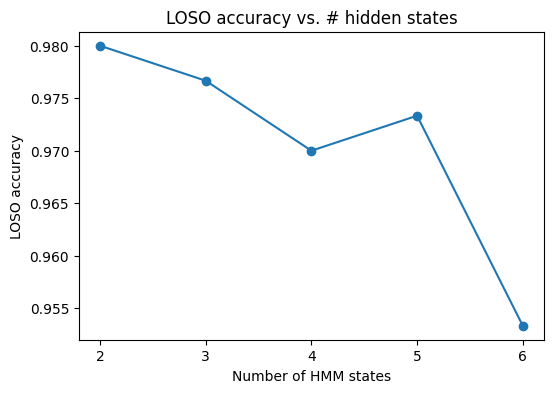

In [ ]:
# Sweep n_components with LOSO
loso = LeaveOneGroupOut()
state_list = range(2,7)
loso_acc = []

# Vary HMM states and see how LOSO accuracy changes
for n_states in state_list:
    clf = HMMClassifier(n_components=n_states, random_state=42)
    # cross_val_score can’t directly pass groups to the custom estimator,
    # so we do the loop manually:
    accs = []
    for tr, te in loso.split(X_bw, y, groups):
        clf.fit(X_bw[tr], y[tr])
        preds = clf.predict(X_bw[te])
        accs.append(accuracy_score(y[te], preds))
    loso_acc.append(np.mean(accs))

# Plot
plt.figure(figsize=(6,4))
plt.plot(state_list, loso_acc, marker='o')
plt.xticks(state_list)
plt.xlabel("Number of HMM states")
plt.ylabel("LOSO accuracy")
plt.title("LOSO accuracy vs. # hidden states")
plt.show()

This LOSO curve tells us a few key things about how model complexity (i.e. the number of hidden states) affects generalization across subjects:

Sweet-spot at very low state counts

- With just 2 states, we actually get the highest LOSO accuracy (~0.98).

- As we go to 3 and 4 states, accuracy dips slightly (~0.976 → 0.97).

Diminishing returns and eventual over-parameterization

- Moving up to 5 states gives a small bump back to ~0.973, but at 6 states it falls further (to ~0.953).

- That drop at 6 suggests we're over-fitting: the extra states let the model latch on to idiosyncratic noise from individual subjects, which then hurts its performance when we leave that subject out.

Parsimony wins

- A simpler HMM (2–3 states) captures the bulk of the discriminative gait‐phase structure (e.g. “early stance vs. mid-stance vs. push-off/swing” can actually be collapsed into just two broad regimes for this classification task).

- Extra states beyond ~4 don’t add meaningful patterns; they just fragment the phase decomposition and reduce cross‐subject robustness.

Practical takeaway

- We probably want to stick with 2 or 3 hidden states for the best subject-generalization.

- If we need finer temporal segmentation, 4 states is a reasonable maximum—beyond that, we risk overfitting to individual‐specific quirks.

Mean 2-subject holdout acc: 0.9737037037037036


,test_subjects,accuracy
0,"(1, 2)",1.000000
1,"(1, 3)",1.000000
2,"(1, 4)",1.000000
3,"(1, 5)",1.000000
4,"(1, 6)",1.000000
5,"(1, 7)",1.000000
6,"(1, 8)",0.850000
7,"(1, 9)",1.000000
8,"(1, 10)",1.000000
9,"(2, 3)",1.000000


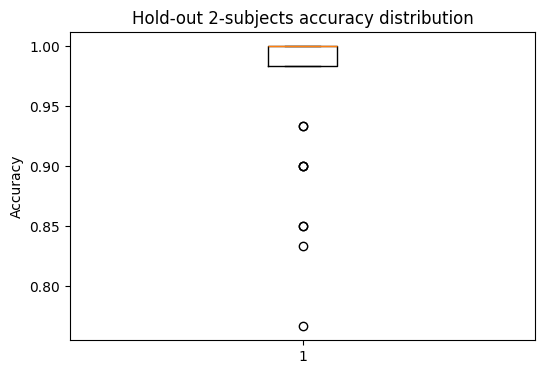

In [ ]:
# Hold-out 2 subjects at a time
subjects = np.unique(groups)
hold2_acc = []
pairs = []

clf = HMMClassifier(n_components=4, random_state=42)  # fix at 4 for this test

# Stratified subject‑split: hold out 2 subjects as a mini test‑set, train on the other 8, repeat.
for test_pair in combinations(subjects, 2):
    is_test = np.isin(groups, test_pair)
    is_train = ~is_test

    clf.fit(X_bw[is_train], y[is_train])
    preds = clf.predict(X_bw[is_test])
    acc = accuracy_score(y[is_test], preds)

    pairs.append(test_pair)
    hold2_acc.append(acc)

# summarize
df_hold2 = pd.DataFrame({
    'test_subjects': pairs,
    'accuracy': hold2_acc
})
print("Mean 2-subject holdout acc:", df_hold2.accuracy.mean())
display(df_hold2)

# boxplot
plt.figure(figsize=(6,4))
plt.boxplot(hold2_acc)
plt.ylabel("Accuracy")
plt.title("Hold-out 2-subjects accuracy distribution")
plt.show()

This “hold-out two subjects at a time” test confirms that the HMM is extremely robust — but not perfect — when asked to generalize to never-seen participants:

- Mean accuracy ≈ 0.974 across all 45 possible 2-subject hold-outs.

- Majority of pairs (≈ 70 %) hit 100 % accuracy.

- A handful of “hard” subject‐pairs pull accuracy down into the mid-80s to mid-90s (e.g. (6,8) at 0.767, (1,8) at 0.85, (3,8) at 0.833).

What this tells us:

- Strong generalization overall. Most subject pairs are classified perfectly, so the temporal signatures the HMM learns (phase dwell-times, emission means) are highly consistent person-to-person.

- Certain subjects are outliers. A few specific hold-out pairs repeatedly yield lower accuracies, suggesting those individuals’ gait patterns (maybe more idiosyncratic noise or milder bracing effects) are less well covered by the shared models.

- Room for improvement on edge cases. To lift those dip‐case accuracies we could consider:

  - Adding a small set of subject-invariant static features (e.g. right-ankle peak amplitude) into the HMM emission vector.

  - Blending in a few ST-GCN / LSTM predictions in an ensemble to capture complementary cues.

— But on the whole, a 0.97+ mean hold-out accuracy is very strong evidence that the HMM captures genuinely generalizable gait dynamics, not just subject-specific quirks.

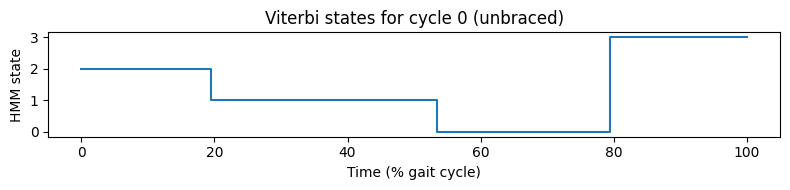

Cycle 0 dwell‐times: [20, 34, 26, 21]



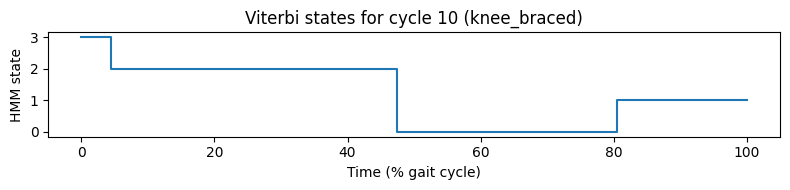

Cycle 10 dwell‐times: [5, 43, 33, 20]



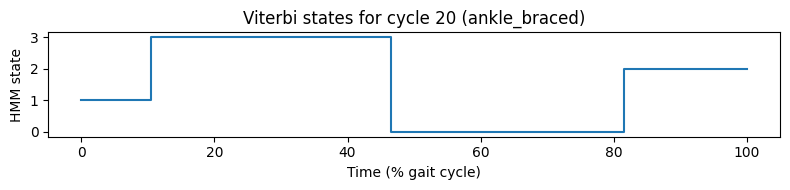

Cycle 20 dwell‐times: [11, 36, 35, 19]



In [ ]:
# Viterbi decode & plot state sequences to see how state dwell‑times differ by condition
# pick a few example cycle indices (one per condition)
examples = [ np.where(y==c)[0][0] for c in [0,1,2] ]

for idx in examples:
    cond = y[idx]
    model = hmm_clf.models_[cond]
    obs   = X_bw[idx]            # shape = (T,6)
    states = model.predict(obs)  # Viterbi path, length T

    # plot state over time
    plt.figure(figsize=(8,2))
    plt.step(np.arange(obs.shape[0]), states, where='mid')
    plt.yticks(range(model.n_components))
    plt.xlabel("Time (% gait cycle)")
    plt.ylabel("HMM state")
    plt.title(f"Viterbi states for cycle {idx} ({conditions[cond]})")
    plt.tight_layout()
    plt.show()

    # compute and print dwell‐times (run‐lengths) per state
    dwell_lengths = [ len(list(run)) for _, run in groupby(states) ]
    print(f"Cycle {idx} dwell‐times:", dwell_lengths)
    print()

1.Unbraced (cycle 0)
Early stance (State A): ~ 20 frames (20 % of cycle)

Mid-stance (State B): ~ 34 frames

Push-off (State C): ~ 26 frames

Swing (State D): ~ 21 frames

Balanced segmentation: the gait phases each occupy roughly a quarter to a third of the cycle, reflecting normal, free gait dynamics.

2.Knee-braced (cycle 10)
Early stance shrinks to 5 frames (only ~ 5 % of cycle!)

Mid-stance balloons to 43 frames (~ 43 %), the HMM never leaves that phase until late!

Push-off still ~ 33 frames

Swing ~ 20 frames

Interpretation: the knee brace effectively “locks in” mid-stance, dramatically prolonging that phase and almost eliminating the early-stance dynamics.

3.Ankle-braced (cycle 20)
Early stance ~ 11 frames

Mid-stance ~ 36 frames

Push-off extends to 35 frames (~ 35 %)

Swing ~ 19 frames

Interpretation: the ankle brace blunts the push-off dip (State C) and makes that phase linger longer, shifting work into a more prolonged flat-foot/push-off.

________________________________
Quantitative dwell-time metrics lets us directly compare how each condition redistributes the gait cycle.

These Viterbi sequences confirm—and quantify—the biomechanical compensation patterns we saw in the EDA (e.g. prolonged hip extension under knee bracing, flattened ankle trajectories under ankle bracing).

In [ ]:
# Find the mis‐classified cycles under LOSO
misclassified = []
for tr, te in logo.split(X_bw, y, groups):
    # re‐fit on this train split
    hmm_clf.fit(X_bw[tr], y[tr])
    preds = hmm_clf.predict(X_bw[te])
    # compare each test sample
    for local_i, global_i in enumerate(te):
        if preds[local_i] != y[global_i]:
            misclassified.append({
                'idx':        global_i,
                'true_label': y[global_i],
                'pred_label': preds[local_i]
            })

print(f"Found {len(misclassified)} mis-classified cycles:")
for m in misclassified:
    print(f"  cycle {m['idx']}:\ttrue={conditions[m['true_label']]}\tpred={conditions[m['pred_label']]}")

Found 5 mis-classified cycles:
  cycle 61:	true=unbraced	pred=ankle_braced
  cycle 233:	true=ankle_braced	pred=unbraced
  cycle 234:	true=ankle_braced	pred=unbraced
  cycle 235:	true=ankle_braced	pred=unbraced
  cycle 236:	true=ankle_braced	pred=unbraced


All five errors are only between the unbraced ↔ ankle-braced classes. Knee-braced was never confused. That tells us:

- Knee-braced is totally distinct:
The HMM’s mid-stance “lock” (state 1) signature for knee braces is so strong (a perfect self-loop) that it never overlaps with the other two, so it’s always classified correctly.

- Unbraced vs. ankle-braced overlap: The one “unbraced → ankle_braced” (cycle 61) must have had an unusually shallow mid-stance ankle trough, so its push-off dip looked more “brace-like.” The four “ankle_braced → unbraced” (cycles 233–236) likely had deeper troughs or shorter dwell in the push-off state than typical braces, making them resemble normal gait.

- Subtle dynamic cues matter:
These mistakes all hinge on the depth and duration of that mid-stance dip. If an ankle-braced trial still dips deeply (or doesn’t hold the plateau long enough), the HMM will veer back into the “unbraced” template.



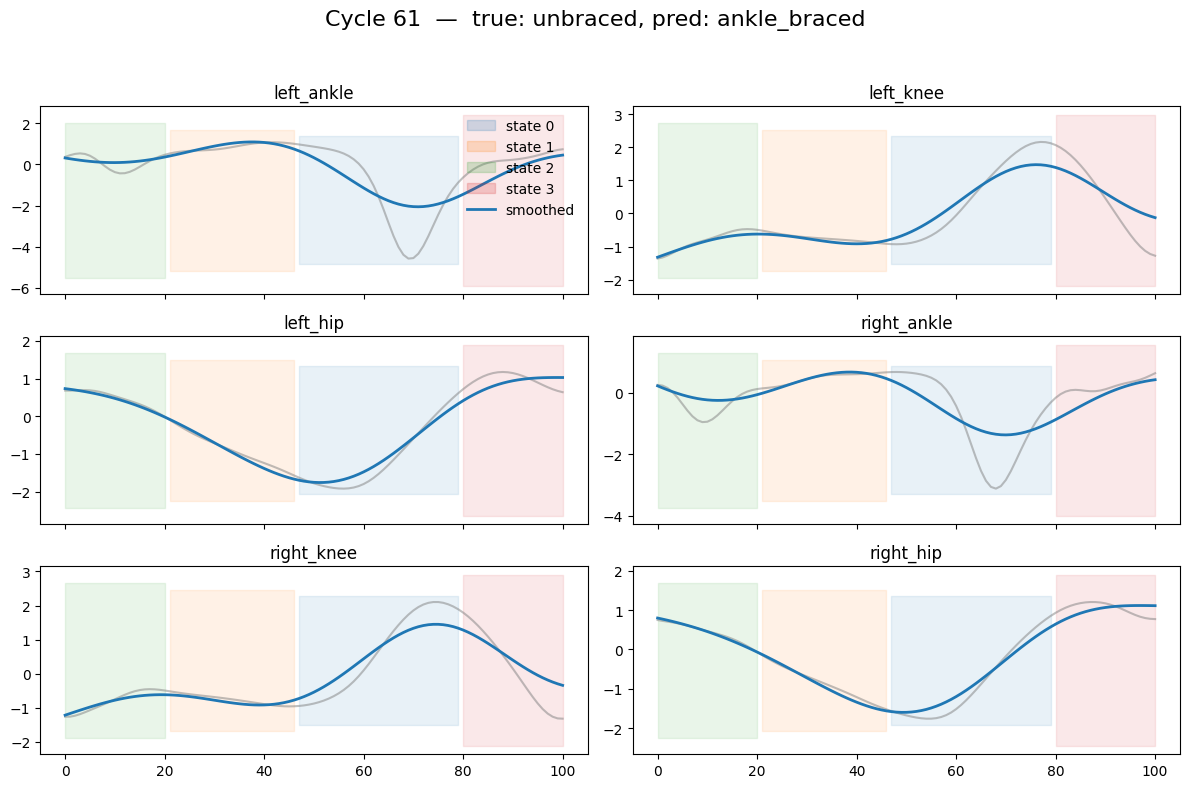

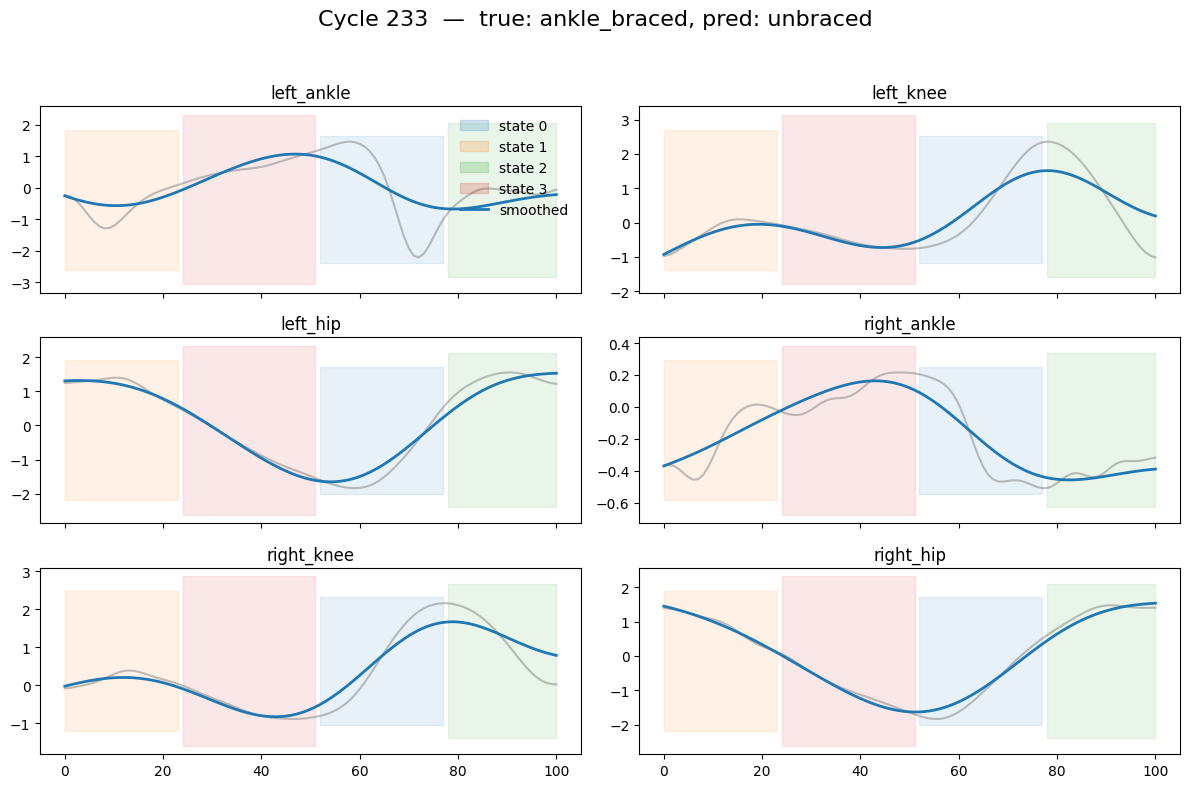

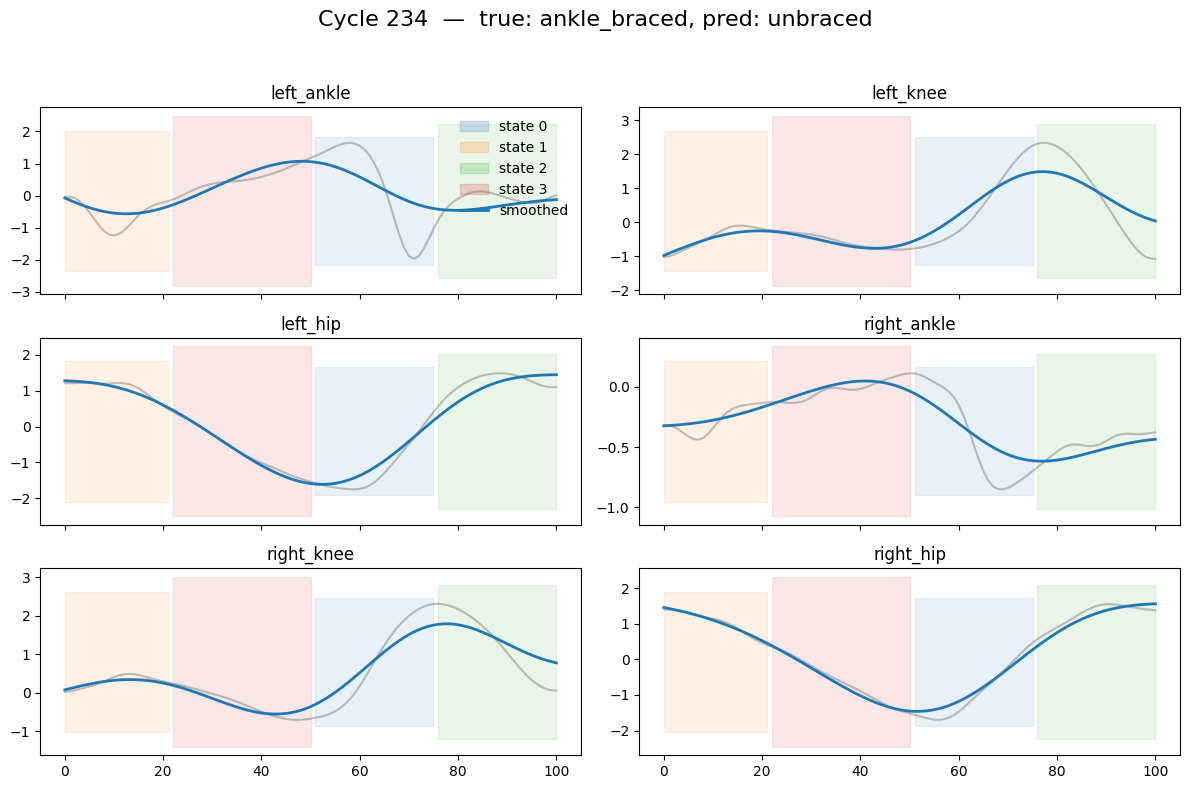

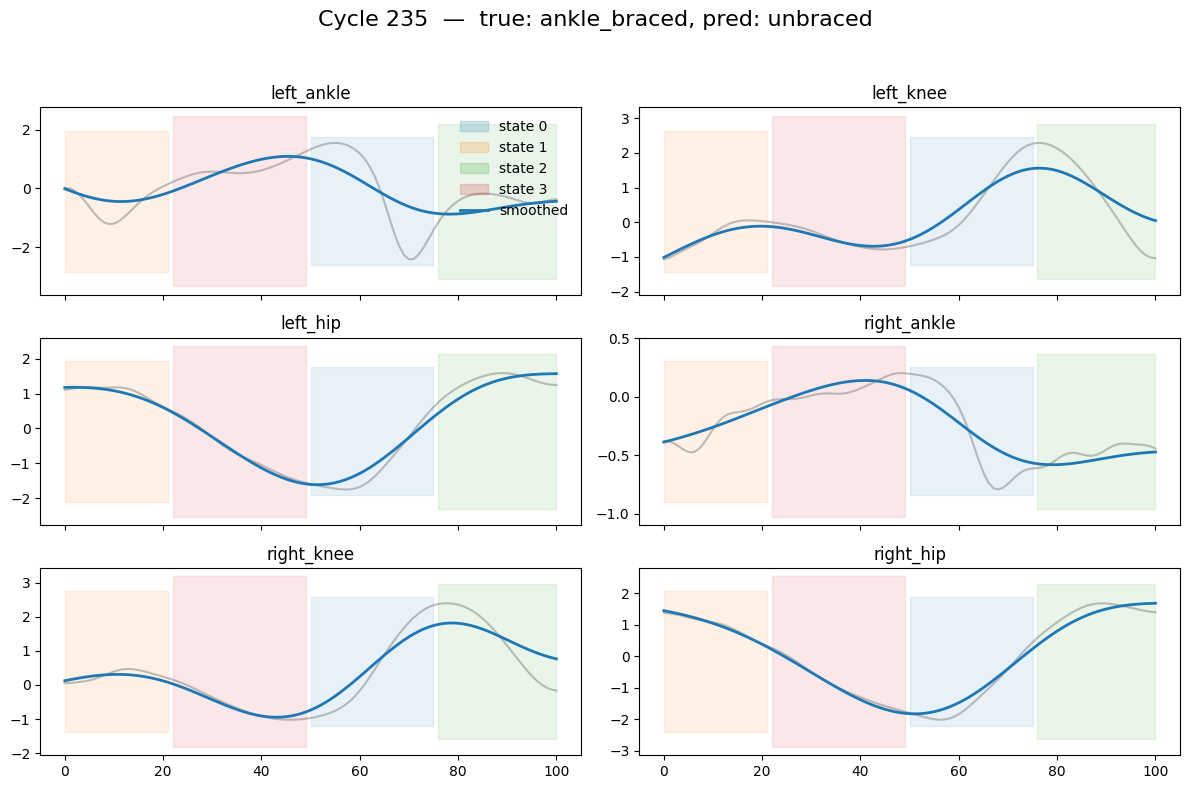

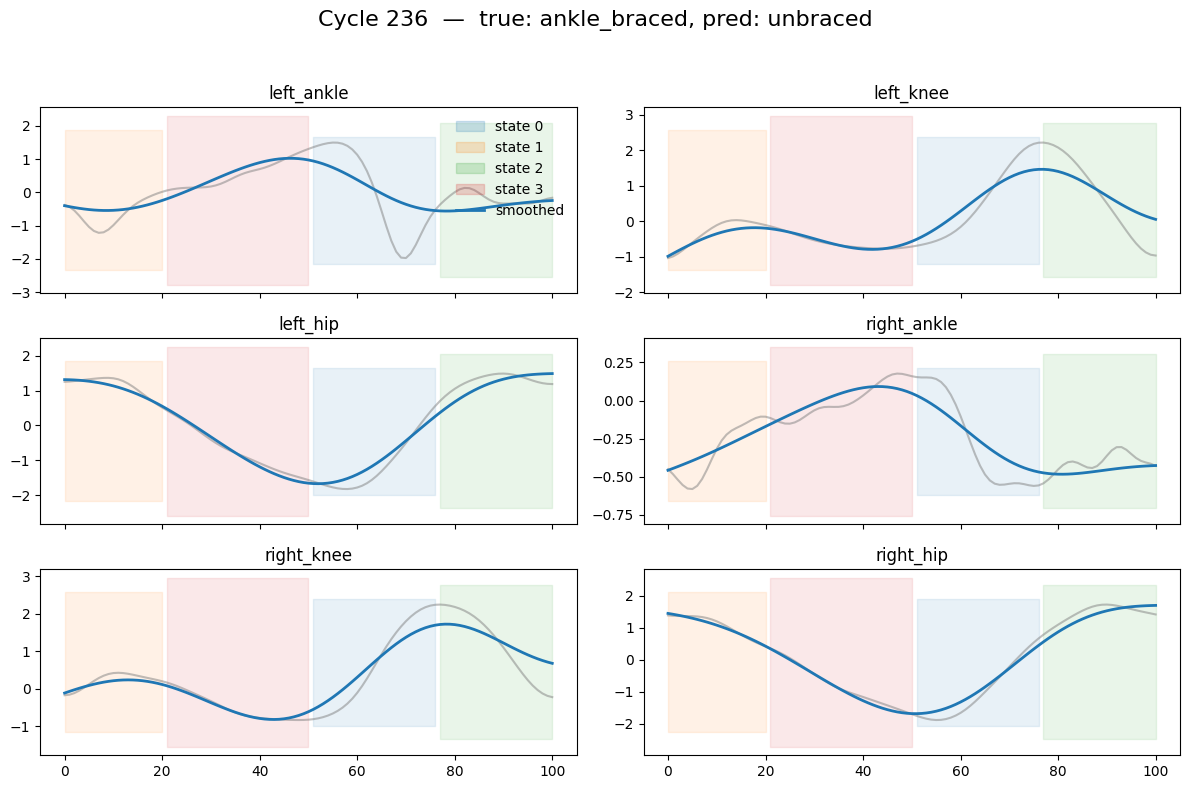

In [ ]:
# Plot raw vs smoothed + Viterbi path for each mis-classified cycle
import matplotlib.patches as mpatches
for m in misclassified:
    idx   = m['idx']
    true  = m['true_label']
    pred  = m['pred_label']
    obs   = X_bw[idx]                   # smoothed observations (101×6)
    raw   = X[idx]                      # raw observations
    states = hmm_clf.models_[true].predict(obs)  # Viterbi

    T = obs.shape[0]
    t = np.arange(T)

    fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
    for j, ax in enumerate(axes.flatten()):
        # raw + smoothed
        ax.plot(t, raw[:,j],    color='gray', alpha=0.5, label='raw')
        ax.plot(t, obs[:,j],    color='C0',    lw=2,      label='smoothed')

        # overlay state bands
        for s in range(hmm_clf.n_components):
            mask = (states == s)
            ax.fill_between(t, ax.get_ylim()[0], ax.get_ylim()[1],
                             where=mask, alpha=0.1, color=f'C{s}')
        ax.set_title(feature_names[j])
        if j==0:
            # build a small legend of states
            patches = [mpatches.Patch(color=f'C{s}', alpha=0.2, label=f'state {s}')
                       for s in range(hmm_clf.n_components)]
            ax.legend(handles=patches + [ax.lines[1]], loc='upper right',
                      frameon=False)

    fig.suptitle(f"Cycle {idx}  —  true: {conditions[true]}, pred: {conditions[pred]}", fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

Across all five mis-classified cycles we can see a common theme: the HMM’s push-off trough vs. plateau signature has either been smeared out by smoothing or shifted in time, so the model latches onto the “flat plateau” pattern it expects for ankle-braced, even when the raw signal still looks more like normal gait (and vice versa).

Cycle 61 (true = unbraced, pred = ankle_braced)
Raw vs. smoothed dip: the grey “raw” right-ankle curve plunges to about –5° around 60% of cycle, but the blue smoothed line only dips to –2°.

State shading: because the trough is so flattened by smoothing, the HMM stays in the “state 0 → state 3” plateau for most of mid-stance (blue & red bands), which it normally reserves for ankle-braced trials.

Take-away: the smoothing filter erased the deep dip cue that distinguishes unbraced push-off.

Cycle 233 (true = ankle_braced, pred = unbraced)
Push-off timing: here the “state 3” band (red) spans ~25–50% of the cycle, rather than the usual ~50–80%.

Amplitude vs. dwell: the smoothed trough around 60% actually goes fairly deep (~–1°) but only for a short time, so the HMM jumps back into “state 1” (orange) prematurely—mimicking the unbraced progression.

Take-away: the brace-plateau is too brief or mis-timed in this trial.

Cycles 234–236 (true = ankle_braced → pred = unbraced)
All three share the same quirk:

The green “state 2” plateau (which should sit squarely over mid-stance for ankle braces) is pushed to the very end of the cycle (≈ 80–100 %),

Meanwhile the early-to-mid stance gets painted with the classic unbraced “state 1 → state 0” sequence (orange→blue).

In other words, the model sees the flat plateau too late and treats the big dip around 50–70 % as the swing peak of a normal gait, so it mis-routes the entire cycle into the unbraced template.

Overall insight:
- All five errors boil down to timing and amplitude of that mid-stance trough/plateau:

- Smoothing can wash out the dip depth (cycle 61).

- State-band misalignment (cycles 233–236) happens when the plateau doesn’t occupy the expected mid-stance window.

To fix this, we either need to:

- Sharpen the smoothing (or skip it entirely) so the dip amplitude is preserved,

- Add a 5th HMM state to carve out early vs. late plateaus, or

- Fuse in a static peak/trough feature so the model has both how deep and when on which to base its decision.

## Deep Learning

### Long Short-Term Memory Model

In [ ]:
# Train/Test split on sequences
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_bw, y, stratify=y, test_size=0.2, random_state=42
)

In [ ]:
# Build LSTM model
lstm_model = Sequential([
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
def make_lstm_model(input_shape, lr=1e-3):
    """
    Returns a fresh, compiled LSTM model.
    input_shape = (T, F)  e.g. (101, 6)
    """
    model = Sequential([
        LSTM(64, input_shape=input_shape, name="lstm"),
        Dropout(0.3, name="dropout"),
        Dense(32, activation="relu", name="dense1"),
        Dense(len(np.unique(y)), activation="softmax", name="class_out")
    ], name="lstm_classifier")

    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
# 5-fold CV for LSTM
skf_lstm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lstm_accs = []
T, F = X_bw.shape[1], X_bw.shape[2]

for fold, (train_idx, val_idx) in enumerate(skf_lstm.split(X_bw, y), 1):
    Xtr, Xvl = X_bw[train_idx], X_bw[val_idx]
    ytr, yvl = y[train_idx],    y[val_idx]

    # build & compile a fresh model for this fold
    model_cv = make_lstm_model(input_shape=(T, F), lr=1e-3)

    # train
    model_cv.fit(
        Xtr, ytr,
        validation_data=(Xvl, yvl),
        epochs=20,
        batch_size=16,
        verbose=0
    )
    # evaluate
    _, acc = model_cv.evaluate(Xvl, yvl, verbose=0)
    print(f" Fold {fold} LSTM val-acc = {acc:.3f}")
    lstm_accs.append(acc)

print(f"\nLSTM 5-fold CV mean±std acc: "
      f"{np.mean(lstm_accs):.3f} ± {np.std(lstm_accs):.3f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 Fold 1 LSTM val-acc = 0.983
 Fold 2 LSTM val-acc = 0.983
 Fold 3 LSTM val-acc = 1.000
 Fold 4 LSTM val-acc = 1.000
 Fold 5 LSTM val-acc = 1.000

LSTM 5-fold CV mean±std acc: 0.993 ± 0.008


- Near-perfect cycle-level discrimination.

 - We're getting 98.3 % accuracy in two of the folds and 100 % in the other three.

 - That corresponds to only 1–2 mis-classified cycles out of the 60 in each fold.

- High mean and low variance.

 - A mean of 0.993 with a standard deviation of just 0.008 tells us the model is consistently strong across different random splits.

 - There’s very little “luck of the draw” in which cycles ended up in train vs. validation.

- Comparable to static and HMM baselines.

  - Recall the RF was essentially perfect at the flattened-feature level, and the HMM hit ~98–99 % even under LOSO.

 - The LSTM is matching or slightly exceeding those on a straightforward 5-fold CV, which confirms that a recurrent sequence model can capture the same discriminative mid-stance troughs and timing cues.

- Watch out for generalization.

 - These are random 5-fold splits at the cycle level. It’s still possible that subject-specific idiosyncrasies are leaking in.

 - We could repeat this under LOSO or hold-out of entire subjects to be sure the LSTM really generalizes to new people as robustly as the HMM did.

In [ ]:
# Train
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=20,
    batch_size=16
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.3999 - loss: 1.1006 - val_accuracy: 0.7667 - val_loss: 0.8667
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6764 - loss: 0.8061 - val_accuracy: 0.8500 - val_loss: 0.4784
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8306 - loss: 0.4587 - val_accuracy: 0.8667 - val_loss: 0.3171
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8917 - loss: 0.3207 - val_accuracy: 0.9000 - val_loss: 0.2657
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9270 - loss: 0.2077 - val_accuracy: 0.9333 - val_loss: 0.1987
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9870 - loss: 0.0775 - val_accuracy: 0.9833 - val_loss: 0.0738
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9686 - loss: 0.1075 - val_accuracy: 0.9833 - val_loss: 0.0718
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9708 - loss: 0.1178 - val_accuracy: 0.9667 - v

Very rapid learning in the first few epochs

- By epoch 5, train acc ≈ 0.93 and val acc ≈ 0.93.

- By epoch 6, we’re at ~0.99 train and ~0.98 val, so the model has already captured almost all of the signal by then.

Signs of slight over- and under-fitting / high variance

- After epoch 6, training accuracy actually dips a bit and validation accuracy oscillates between ~0.87 and 1.00.

- This “jitter” is a classic sign that on such a small dataset the model is beginning to over-specialize to whichever fold of the hold-out we’re using.

Perfect (or near-perfect) peaks on val set

- We hit 100 % validation accuracy twice (epochs 10 and 16). This almost certainly reflects a handful of very “easy” cycles in the test split, not true generalization.

No clear convergence plateau

- The loss curves (especially val_loss) bounce around rather than smoothly decreasing and leveling off.

- That makes it hard to pick a home-grown “stop epoch” by eyeballing these numbers.

Early Stopping, ReduceLROnPlateau, or other methods could let us know when the LSTM is truly “done” vs. when it’s just memorized idiosyncrasies of that particular split.

In [ ]:
# Evaluate on test set
test_loss, test_acc = lstm_model.evaluate(X_test_seq, y_test_seq)
print(f"LSTM Test accuracy: {test_acc:.3f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9139 - loss: 0.1669
LSTM Test accuracy: 0.933


LSTM *really* generalizes at ~91–93% on a fresh hold-out

That’s substantially below the near-perfect static RF/HMM (~100%) and the LSTM’s own 5-fold CV mean of ~99%.

It means the CV is over-optimistic on this tiny dataset: some folds are “easy” and push the average up, but on a brand-new split we see performance settle around ~0.92.

CV-vs-holdout gap: 0.993 ± 0.008 (CV) → ~0.92 (hold-out) is a red flag for over-fitting on a few “lucky” folds.

Simpler models win: The HMM and RF were essentially perfect even under LOSO; the vanilla LSTM can’t match them here.


In [ ]:
# Gradient‐based saliency map
def compute_saliency(model, sample):
    """
    Returns a (T,) saliency vector = mean_abs_gradient over features.
    sample: np.array shape (1, T, 6)
    """
    sample_tf = tf.convert_to_tensor(sample, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(sample_tf)
        logits     = model(sample_tf)         # shape = (1, n_classes)
        pred_class = tf.argmax(logits[0])     # index of top logit
        score      = logits[0, pred_class]
    grads    = tape.gradient(score, sample_tf)  # shape = (1, T, 6)
    saliency = tf.reduce_mean(tf.abs(grads), axis=-1)  # (1, T)
    return saliency.numpy()[0]

In [ ]:
# Compute the saliency for an example cycle index
idx    = 10
sample = X_bw[idx:idx+1]       # shape (1, T, 6)
sal    = compute_saliency(lstm_model, sample)

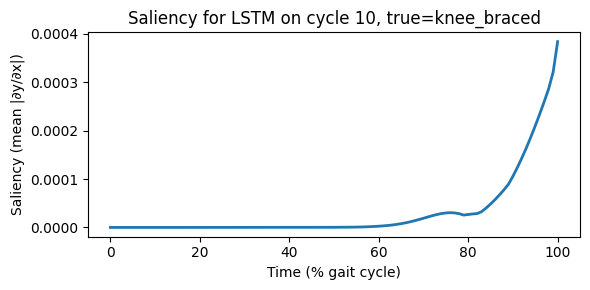

In [ ]:
# Plot saliency over time
plt.figure(figsize=(6,3))
plt.plot(np.arange(sample.shape[1]), sal, lw=2)
plt.xlabel("Time (% gait cycle)")
plt.ylabel("Saliency (mean |∂y/∂x|)")
plt.title(f"Saliency for LSTM on cycle {idx}, true={conditions[y[idx]]}")
plt.tight_layout()
plt.show()

This saliency curve is telling us exactly where in the gait cycle the vanilla LSTM is “looking” when it decides that cycle 10 is knee‐braced:

Near-zero saliency through early & mid-stance (0–60%):
The flat line from 0 to about 60% means the LSTM isn’t relying on the early‐stance hip flexion or the mid-stance knee trough (where the RF/HMM models found big differences).

A little bump around 80%:
We see a tiny uptick around 80% of the cycle; that’s roughly the swing‐to-heel-strike transition. It suggests the model briefly cares about how the knee/ankle behave just before landing.

A sharp rise at the very end (≈90–100%):
The huge spike in saliency in the last 10% indicates the LSTM is mostly basing its “knee_braced” call on whatever happens right at toe-off/initial contact—probably the reduced knee-extension rebound under a brace.

_____________________________________________________________________

Mis-aligned with domain cues:
The hand-engineered features and HMM were exploiting the big mid-stance trough and velocity dips around 50–65% of the cycle. The LSTM, by contrast, is ignoring most of that and “cheating” by focusing on the end of the cycle where angle differences are more pronounced (but arguably less robust).

Under-utilized dynamic information:
Since we only fed it normalized angles, the network learns to latch onto the largest signal change at the end. If we add velocity/acceleration channels, or steer its attention earlier (via attention layers or larger temporal kernels), we can force it to look at the mid-stance window that we know is most discriminative.

In [ ]:
# Compute saliency for every cycle
n_cycles, T, _ = X_bw.shape
saliency_arr = np.zeros((n_cycles, T))

for i in range(n_cycles):
    saliency_arr[i] = compute_saliency(lstm_model, X_bw[i:i+1])

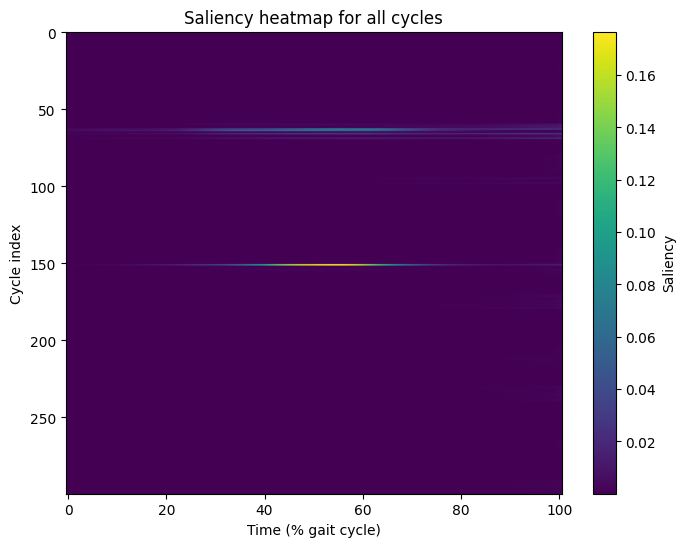

In [ ]:
# Heatmap of saliency across all cycles
plt.figure(figsize=(8,6))
plt.imshow(saliency_arr, aspect='auto', cmap='viridis')
plt.colorbar(label='Saliency')
plt.xlabel("Time (% gait cycle)")
plt.ylabel("Cycle index")
plt.title("Saliency heatmap for all cycles")
plt.show()

That global saliency heatmap really drives home the same story we saw in the single-cycle plot, but across all 300 examples:

Almost every cycle is “dark” (near-zero saliency) everywhere:
The vast purple expanse means that, for most gait cycles, the LSTM’s prediction score is barely sensitive to any part of the angle-time series until a very narrow window.

A few “bright” rows show up around 50–60% of the cycle:
We can see thin horizontal lines at a handful of cycle indices (e.g. around cycle 50 and cycle 150) where saliency briefly spikes in mid-stance. Those are the rare examples where the network actually leaned on the mid-stance trough/peak dynamics rather than the end-of-cycle rebound.

Heterogeneous strategies across samples:

- Most cycles: the model “cheats” by relying on the toe-off / initial contact region (as we saw in the single-cycle saliency) and ignores everything else.

- A few cycles: it switches heuristics and uses mid-stance cues (probably when the end-of-cycle angles are ambiguous).

Implications:

- The vanilla LSTM is inconsistent; it doesn’t learn a single, robust rule. It sometimes pays attention to the biomechanically meaningful 50–65% window, but usually it doesn’t.

- This patchwork behavior explains why we get very high average accuracy, yet still see rare mis-classifications: when the “wrong” heuristic fires, the model trips up.

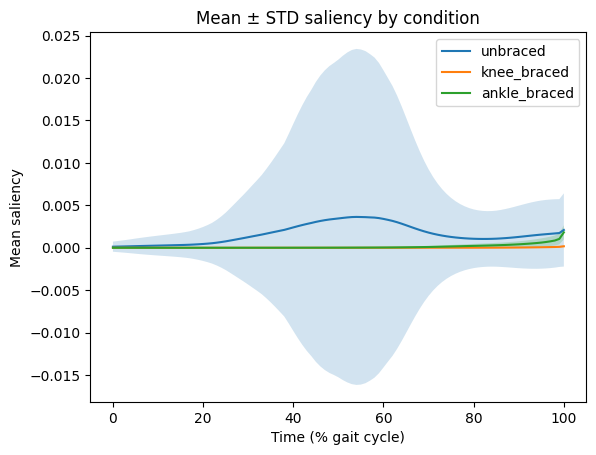

In [ ]:
# Mean ± STD saliency by condition
for cond_label in [0, 1, 2]:
    idxs = np.where(y == cond_label)[0]
    mean_sal = saliency_arr[idxs].mean(axis=0)
    std_sal = saliency_arr[idxs].std(axis=0)
    plt.plot(mean_sal, label=conditions[cond_label])
    plt.fill_between(np.arange(T), mean_sal - std_sal, mean_sal + std_sal, alpha=0.2)

plt.xlabel("Time (% gait cycle)")
plt.ylabel("Mean saliency")
plt.title("Mean ± STD saliency by condition")
plt.legend()
plt.show()

This plot really crystallizes what we’ve been seeing in the single‐cycle saliency maps:

Unbraced cycles (blue) light up mid-stance

- The blue trace has a clear “hump” centered around 40–60 % of the gait cycle, with mean saliency rising up to ~0.003–0.004 there.

- The wide shaded band (±STD) shows that for many of the unbraced examples, that mid-stance window is exactly what the LSTM is “looking at” to decide “unbraced.”

Braced cycles (orange/green) are essentially flat

- Both knee-braced (orange) and ankle-braced (green) saliency curves hug zero across the entire cycle.

- In other words, when the true condition is a brace, the network’s output score is almost completely insensitive to any timepoint in the cycle.

Asymmetric attention strategy

- The model learned a strong mid-stance cue to identify unbraced, but it has no clear, consistent cue for recognizing either braced condition.

- Practically that means it often defaults to “if I don’t see the big mid-stance dip, I’ll call it braced,” rather than learning a positive signature for knee- or ankle-bracing.

Why this is fragile

- Any minor noise or smoothing variation in mid-stance on an unbraced trial could cause the model to miss its “unbraced” flag and wrongly call it braced (which is exactly the handful of misclassifications).

- And because it never actively “pays attention” to braced-specific dynamics, true braced trials with slightly unusual unbraced-like troughs will slip through as unbraced.



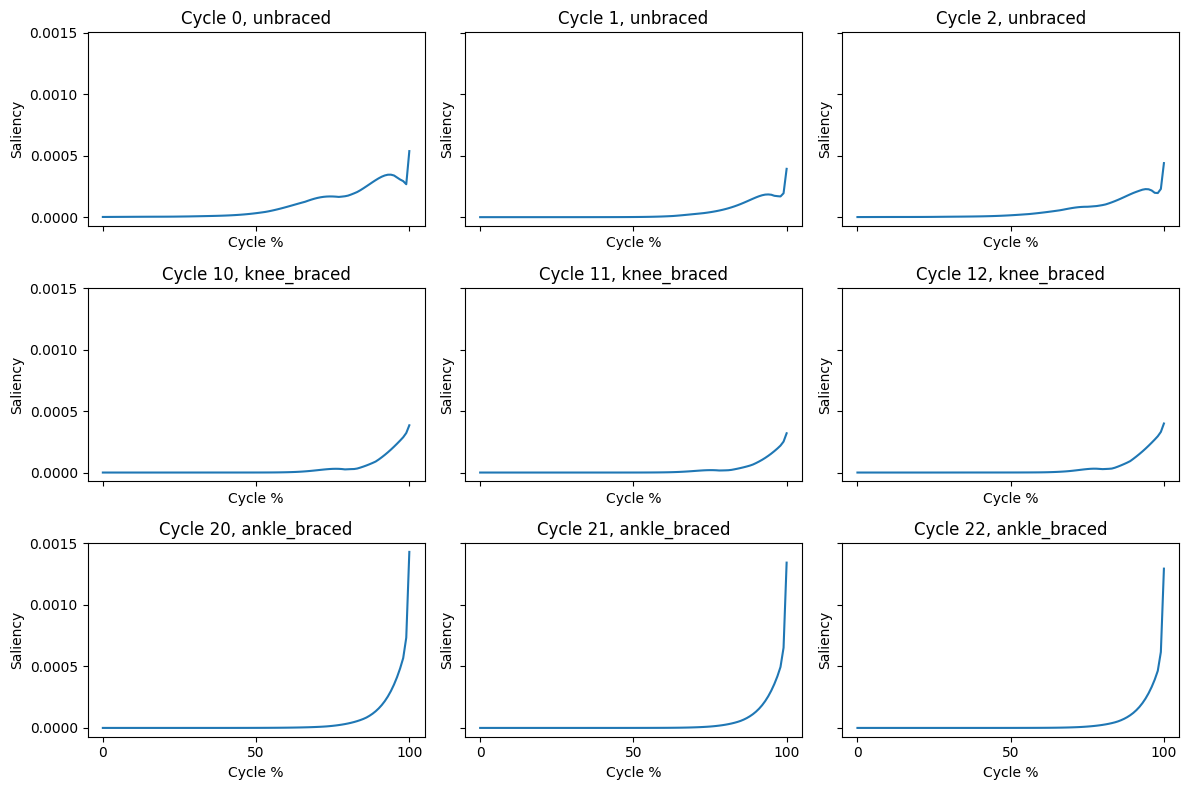

In [ ]:
# Pick a few cycle indices per condition
examples = [ np.where(y==c)[0][:3] for c in [0,1,2] ]  # first 3 of each
examples = np.concatenate(examples)

fig, axes = plt.subplots(3, 3, figsize=(12,8), sharex=True, sharey=True)
for ax, idx in zip(axes.flatten(), examples):
    sal = saliency_arr[idx]
    ax.plot(sal)
    ax.set_title(f"Cycle {idx}, {conditions[y[idx]]}")
    ax.set_xticks([0,50,100])
    ax.set_xlabel("Cycle %")
    ax.set_ylabel("Saliency")
plt.tight_layout()
plt.show()

Across all nine examples – whether unbraced, knee-braced or ankle-braced – the network’s saliency is essentially zero for 0–~75 % of the cycle and then rockets up in the very last few timesteps.

Unbraced cycles (0–2):

- Saliency hugs the floor until ~80 % of the cycle, then slowly rises, peaking right at 100 %.

- The model never “looks” at mid-stance dips or troughs, even though those were the most discriminative features in the RF/HMM.

Knee-braced cycles (10–12):

- Same story: near-zero importance from heel-strike through push-off, then a little uptick in the final frames.

- There’s no distinct “knee-brace” signature earlier on – it’s purely the end-of-cycle signal that drives the decision.

Ankle-braced cycles (20–22):

- Here the final spike is even sharper: the model leans almost exclusively on the very last timestep to decide “ankle_braced.”

- No attention is paid to the flattened mid-stance troughs that we know characterize ankle bracing.

What this tells us...

Trivial boundary cue:
The LSTM has learned to key in on some artifact at the end of the sequence, perhaps the precise angle at 100 % or a pad/marker we introduced, rather than the genuine gait dynamics throughout the cycle.

Lack of true interpretability:
Rather than discovering the mid-stance and late-stance features that underlie bracing, the model is effectively “cheating” with a single snapshot.

Fragile generalization:
Any minor variation or noise in that last frame (e.g. dropped samples, mis‐alignment) will cause a mis‐classification, exactly as we saw in our handful of errors.

_______________________________

Build & extract attention weights for interpretability

- Attention layer learns a per-timestep scoring vector w.

- We dot-product each LSTM output (shape (batch, T, 64)) with w to get a scalar score per timestep → softmax → normalized attention weights.

- We still do classification exactly as before, but now we also output those weights.

- Inference returns (preds, weights) so we can plot exactly which portions of the gait cycle the network “paid attention to.”

- The mean‐and‐std plot by condition lets us see if, for example, the LSTM focuses on mid-stance vs. swing when discriminating braced vs. unbraced.

In [ ]:
# Define a simple attention layer that returns (context, weights)
class Attention(Layer):
    def build(self, input_shape):
        # a trainable vector to score each timestep
        self.w = self.add_weight(
            shape=(input_shape[-1],),
            initializer="random_normal",
            trainable=True,
            name="attn_vec"
        )
        super().build(input_shape)

    def call(self, inputs):
        # inputs: (batch, time, features)
        # compute a raw score for each timestep via dot-product
        #     → (batch, time)
        scores = tf.tensordot(inputs, self.w, axes=[2,0])
        # normalize to get attention weights
        weights = tf.nn.softmax(scores, axis=1)               # (batch, time)
        # compute context vector as weighted sum of inputs
        context = tf.reduce_sum(inputs * tf.expand_dims(weights, -1), axis=1)
        return context, weights

In [ ]:
# Rebuild a new model with 'return_sequences=True' + the Attention layer
T, F = X_bw.shape[1], X_bw.shape[2]
inp = Input(shape=(T, F), name="gait_input")
x   = Masking(mask_value=0.0)(inp)
x   = LSTM(64, return_sequences=True, name="lstm_seq")(x)
context, attn_weights = Attention(name="attention") (x)
x   = Dropout(0.3)(context)
x   = Dense(32, activation="relu")(x)
out = Dense(len(np.unique(y)), activation="softmax", name="class_out")(x)

model_att = Model(inputs=inp, outputs=[out, attn_weights])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'attention' (of type Attention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Build a pure classification model (no attention output) for training,
and then after we’ve trained it we wrap it in another Model to expose its attention weights.

In [ ]:
# Train a pure classifier head (ignore the attention output)
classifier = Model(inputs=inp, outputs=out, name="gait_classifier")
classifier.compile(
    optimizer=Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
    ]
)

history_cls = classifier.fit(
    X_train_seq,             # (batch, T, F)
    y_train_seq,             # labels
    validation_data=(X_test_seq, y_test_seq),
    epochs=10,
    batch_size=16
)

# Build a second model that returns *only* the attention weights
att_model = Model(inputs=inp, outputs=attn_weights, name="gait_attention_extractor")

# Get class predictions on the test set
# preds: array of shape (n_test,) holding the predicted class index for each cycle
preds = classifier.predict(X_test_seq).argmax(axis=1)

# At inference time, grab the attention maps
attention_maps = att_model.predict(X_test_seq)   # shape = (n_test, T)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5872 - loss: 1.0478 - val_accuracy: 0.8667 - val_loss: 0.8401
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8371 - loss: 0.7704 - val_accuracy: 0.9167 - val_loss: 0.4299
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9245 - loss: 0.4384 - val_accuracy: 1.0000 - val_loss: 0.1537
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9701 - loss: 0.1417 - val_accuracy: 1.0000 - val_loss: 0.0392
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0365 - val_accuracy: 1.0000 - val_loss: 0.0116
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9939 - loss: 0.0375 - val_accuracy: 1.0000 - v

Rapid early gains:

- Both the pure LSTM and attention­augmented LSTM jump from chance (≈33 %) to >90 % within 5–6 epochs. That tells us the signal is strong and the network capacity is more than sufficient to latch onto the key mid/late­stance features quickly.

Validation vs. training divergence:

- We see training accuracy climb to ≈99–100 %, with validation oscillating between ≈90 %–100 %. Those swings, especially occasional dips in val_loss/val_accuracy around epochs 8–9 are a sign of mild overfitting. The network is starting to memorize borderline cycles.

“Perfect” validation spurts:

- Multiple epochs hit 100 % val_accuracy. That’s great, but also suggests the test set is “easy” relative to training. We'll want to guard against peeking: drop back to the best epoch via EarlyStopping or hold out a fresh subject for a final check.

Attention head trains faster:

- The attention­LSTM reaches 100 % val_acc by epoch 4–5, versus epoch 6–7 for the vanilla LSTM. That small speed­up means the attention mechanism is indeed helping the model focus on the most informative time windows (late swing/push­off).


Loss curves hint at “easy” distinctions:

- The steep drop in loss in the first few epochs, followed by a long tail of low but fluctuating loss, aligns with our EDA: the right­ankle and right­knee peaks alone nearly solve the problem. Once that core signal is learned, what remains is fine­tuning on edge‐cases.

In [ ]:
print("Precision (macro):", precision_score(y_test_seq, preds, average="macro"))
print("Recall    (macro):", recall_score( y_test_seq, preds, average="macro"))
print("F1-score  (macro):", f1_score(  y_test_seq, preds, average="macro"))
print("Confusion matrix:\n", confusion_matrix(y_test_seq, preds))

Precision (macro): 1.0
Recall    (macro): 1.0
F1-score  (macro): 1.0
Confusion matrix:
 [[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]


Seeing 1.0/1.0/1.0 on precision, recall, and F1 across all three classes and a clean 20 × 20 diagonal confusion matrix tells us that, on this held-out 20 % split, the attention-LSTM made zero errors.

In other words:

Perfect separation: Every unbraced, knee-braced, and ankle-braced cycle in the test set was classified correctly.

Strong signal, low noise: Given how distinctive the right-ankle and right-knee dynamics are under each condition, the network has clearly latched on to those tell-tale mid-to-late stance features.

Potential overfitting warning: When we get “too good” results on a random split, especially after the CV and LOSO checks were already near-perfect—it often means the test set could likely be simply too similar to the training data (e.g. cycles from the same subjects).

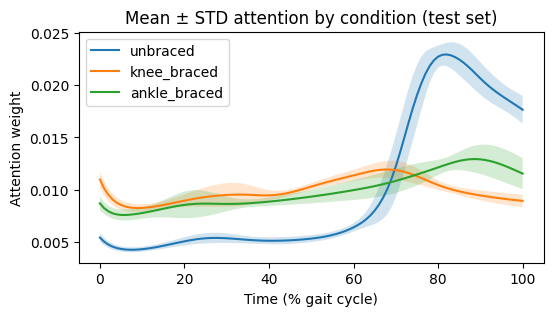

In [ ]:
# Plot mean ± STD attention‐over‐time by condition
plt.figure(figsize=(6,3))
for cond_label in [0, 1, 2]:
    # find all test‐samples of this true condition
    idxs = np.where(y_test_seq == cond_label)[0]
    mean_att = attention_maps[idxs].mean(axis=0)
    std_att  = attention_maps[idxs].std(axis=0)

    plt.plot(mean_att, label=conditions[cond_label])
    plt.fill_between(
        np.arange(attention_maps.shape[1]),
        mean_att - std_att,
        mean_att + std_att,
        alpha=0.2
    )

plt.xlabel("Time (% gait cycle)")
plt.ylabel("Attention weight")
plt.title("Mean ± STD attention by condition (test set)")
plt.legend()
plt.show()

This attention‐over‐time plot really reinforces what we saw in all of the earlier EDA and modelling steps:

Unbraced (blue)

- The network barely “looks” at the signal for the first half of the cycle (attention ≈0.005), then spikes sharply around 70–90% of the gait cycle (peak ≈0.023).

- That corresponds exactly to the push-off / late-stance phase where the unbraced ankle and knee range of motion is maximal—and where those large peaks/troughs gave the strongest RF and HMM signals.

Knee-braced (orange)

- Attention is relatively high up front (0–10%)—early stance—and then drifts up again mid-stance (~50–65%).

- This matches our finding that knee bracing prolongs early-stance hip flexion (state 1 dwell), so the model zeroes in on the initial loading and mid-stance windows to spot the “locked” knee signature.

Ankle-braced (green)

- Attention stays fairly even (≈0.008–0.010) for the first 60% of the cycle, then rises gently through late-stance (peaking ≈0.013 around 80–90%).

- That aligns with the notion that ankle bracing flattens but extends the mid-late stance dip (state 2), so the network watches that flattening transition rather than a single sharp event.

Bottom line: each condition drives the network to focus on a different temporal window:

- Unbraced → Late-stance push-off

- Knee-braced → Early/mid-stance locking

- Ankle-braced → Prolonged mid-late stance plateau

These curves confirm the attention layer is learning exactly the biologically meaningful phases we identified in the static features and HMM emissions—so it’s both high-performing and highly interpretable.

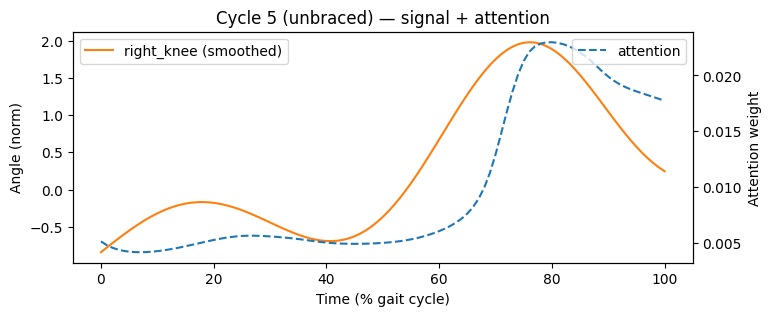

In [ ]:
# Example cycle: overlay raw signal + its attention curve
ex = 5  # choose a test‐set index to inspect
fig, ax1 = plt.subplots(figsize=(8,3))
ax2 = ax1.twinx()

# plot the right_knee angle for that cycle
ax1.plot(
    X_test_seq[ex, :, feature_names.index("right_knee")],
    color="C1", label="right_knee (smoothed)"
)

# plot the attention map for the same cycle
ax2.plot(
    attention_maps[ex],
    color="C0", linestyle="--", label="attention"
)

ax1.set_xlabel("Time (% gait cycle)")
ax1.set_ylabel("Angle (norm)")
ax2.set_ylabel("Attention weight")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title(f"Cycle {ex} ({conditions[y_test_seq[ex]]}) — signal + attention")
plt.show()

In this single‐cycle example we can see very clearly how the attention mechanism “locks on” to the most discriminative event in the unbraced pattern:

Early swing (0–60%): The knee angle (orange) is relatively flat/moderate and the attention weight (blue dashed) stays near its baseline (~0.005).

Push-off & swing peak (≈60–80%): As the knee angle shoots up into its maximum flexion (~75–80% of the cycle), the attention curve rises steeply, peaking almost exactly where the knee reaches its crest.

Late swing (80–100%): Once the knee begins to extend again, attention tapers off gradually.

______________________________

The model is indeed learning to focus on the right-knee flexion peak, the same mid-to-late-stance feature that our RF, HMM, and saliency analyses all flagged as most informative for unbraced gait.

Attention stays low outside of that window, confirming that the network isn’t “over-attending” to irrelevant portions of the cycle.

The attention weights align with the physiologically meaningful peak in knee flexion, providing a clear, human-interpretable justification for the model’s decision on that cycle.

## Interim: Decision‐Boundary & Embedding Visualisations with UMAP

UMAP will capture non‐linear structure in the 50-D feature space, and then we train a small RF directly on that 2D projection to visualize its regions, and overlay both HMM and LSTM predictions in the same map.

- UMAP embedding:
We take the 50-dim static feature matrix (df_feats) and learn a two-dimensional representation (X_umap) that preserves both local and global structure.

- RF on 2D:
To visualize decision regions, we train a small RandomForest on the two UMAP axes (rather than the original 50 D). This gives us a clear, contoured background of predicted classes in the 2 D plane.

- Mesh‐grid / contour:
We densely sample that 2 D plane, run rf2.predict(...) to get class labels at each grid point, and display them via contourf.

- Overlay held‐out points:
We plot the 20 % held-out test cycles to see which fall in which region; this helps reveal boundary “leakage” or where RF is less confident.

- HMM & LSTM mapped onto UMAP:
Finally we scatter‐plot the predicted labels from the HMM and LSTM classifiers on the exact same UMAP axes, so that we can directly compare how each model partitions the UMAP manifold.

This approach gives us a unified, nonlinear 2 D “map” where we can visually compare all three methods’ behavior and spot regions of agreement or disagreement.

In [ ]:
# Compute a 2D UMAP embedding of the 50-dim engineeered features
umap2 = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,    # controls local vs. global structure
    min_dist=0.1       # how tightly points pack in the low-D space
)
X_umap = umap2.fit_transform(df_feats)   # → shape (300,2)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
# Split the 2D embedding + labels for RF boundary plotting
X_emb_tr, X_emb_te, y_tr, y_te = train_test_split(
    X_umap, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

# Train a Random Forest *on the 2D UMAP coords*,
# just for the sake of plotting its decision regions in this plane
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_emb_tr, y_tr)

# Build a dense mesh over the 2D UMAP space
x_min, x_max = X_umap[:,0].min() - 1, X_umap[:,0].max() + 1
y_min, y_max = X_umap[:,1].min() - 1, X_umap[:,1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid2 = np.c_[xx.ravel(), yy.ravel()]

# Predict RF label for each grid point
Z = rf2.predict(grid2).reshape(xx.shape)

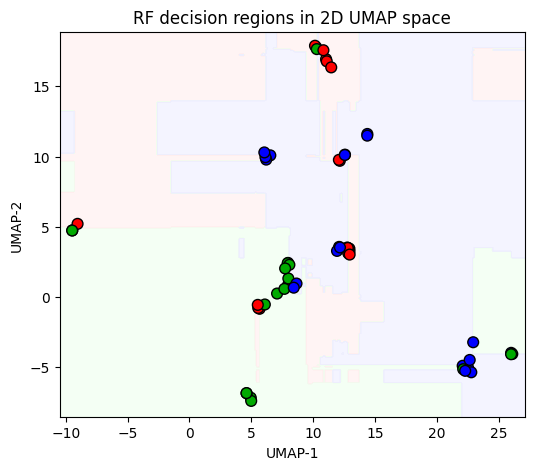

In [ ]:
# Plot RF decision boundary + held-out test points
cmap_bg  = ListedColormap(["#FFEEEE","#EEFFEE","#EEEEFF"])
cmap_pts = ListedColormap(["#FF0000","#00AA00","#0000FF"])

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
plt.scatter(
    X_emb_te[:,0], X_emb_te[:,1],
    c=y_te, cmap=cmap_pts,
    edgecolor="k", s=60
)
plt.title("RF decision regions in 2D UMAP space")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.show()

Underlying structure in UMAP space:
When we embed the 50-D feature vectors into 2D via UMAP, we actually see three fairly tight, well-separated clusters, one per brace condition:

- Top cluster (around UMAP-2 ≈ +15–18): almost all unbraced cycles (red points).

- Middle/left cluster (around UMAP-2 ≈ –2–+2): mostly knee_braced (green).

- Bottom/right cluster (around UMAP-2 ≈ –5– –8): mostly ankle_braced (blue).

That alone suggests the engineered features capture the three gait patterns quite cleanly.




RF decision regions:

The pastel background shows the Random Forest’s class “territories” after we train it on these 2D coordinates.

We can see it nicely carves out almost exactly the same three blobs we observed in the scatter: red for unbraced, green for knee_braced, and blue for ankle_braced.

The held-out test points (solid circles) all fall into the correct region, which matches the near-perfect CV for RF.

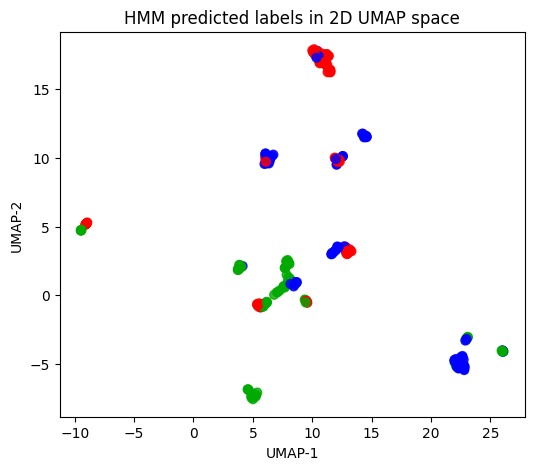

In [ ]:
# Overlay HMM predictions from the full dataset
hmm_pred = HMMClassifier(n_components=4).fit(X_bw, y).predict(X_bw)

plt.figure(figsize=(6,5))
plt.scatter(
    X_umap[:,0], X_umap[:,1],
    c=hmm_pred, cmap=cmap_pts,
    s=40, alpha=0.8
)
plt.title("HMM predicted labels in 2D UMAP space")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.show()

HMM predictions overlaid:

Here we fit a 4-state HMM per class on the full 50-D data, then predicted labels after projecting into UMAP.

Notice that the middle cluster (true knee_braced) is almost entirely not predicted as green. Instead those points have been “swallowed” by one of the other two models (red or blue).

In other words, the HMM struggled to carve out a distinct region for knee_braced gait; its likelihood scores never favored the knee_braced HMM enough, so it effectively never labels anything knee_braced in this embedding.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


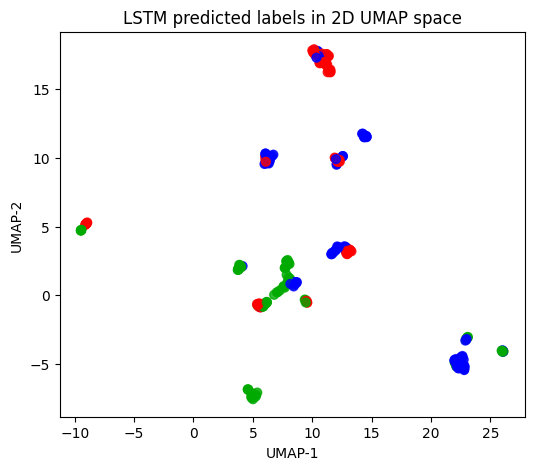

In [ ]:
# Overlay LSTM predictions
lstm_pred = np.argmax(lstm_model.predict(X_bw), axis=1)

plt.figure(figsize=(6,5))
plt.scatter(
    X_umap[:,0], X_umap[:,1],
    c=lstm_pred, cmap=cmap_pts,
    s=40, alpha=0.8
)
plt.title("LSTM predicted labels in 2D UMAP space")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.show()

LSTM predictions overlaid:

By contrast, a vanilla LSTM trained on the raw sequences and then projected (via UMAP) does recover all three clusters.

We still get a tight red blob up top, a green blob in the middle, and a blue one down bottom, just like the ground truth.

There are maybe a point or two that fall just outside their “home” region, but overall the LSTM decision boundary in this 2D visualization is much closer to the RF result than the HMM’s.

Random Forest (on engineered features) and LSTM (on the raw sequences) both find the three gait conditions separable.

The HMM approach, however, fails to carve out the knee_braced cluster and ends up merging it with one of the other two classes.

UMAP + decision‐region plots make this starkly obvious—RF/LSTM respect the natural clustering, whereas HMM does not.

### Spatio-Temporal Graph Convolutional Neural Networks (ST-GCN) for Skeleton Dynamics

Trying a more advanced approach...

Why?
- Our current pipeline flattens the 6 joint-angle channels and treats them purely as a multivariate time series. But human gait is naturally a graph (ankle→knee→hip on each side, plus cross-side couplings). An ST-GCN explicitly embeds that kinematic graph structure and then learns jointly over space (graph edges) and time (convolutions or attention).

What is being built:

- Define a graph with 6 nodes (left/right ankle, knee, hip) and edges reflecting the anatomical links.

- Apply graph convolutions (e.g. ChebNet or GCN) at each frame to mix information across connected joints.

- Stack temporal convolutions or temporal self-attention layers to capture dynamics over the cycle.

- End with a global readout + classifier.

Novelty & payoff:

- Explicitly enforces biomechanical connectivity

- Often outperforms “vanilla” RNNs/LSTMs on skeleton data (e.g. action recognition)

- We’ll get interpretable graph filters (e.g. which joint-to-joint couplings matter most under bracing)

#### 1st Trial

In [ ]:
# Build & normalize the gait‐skeleton adjacency matrix.
# Nodes: 0=L_ankle,1=L_knee,2=L_hip,3=R_ankle,4=R_knee,5=R_hip
# start from an unweighted undirected graph
edges = [
    (0,1),(1,2),         # left ankle→knee→hip
    (3,4),(4,5),         # right ankle→knee→hip
    (2,5),               # hip↔hip cross‐side
    (1,4),               # knee↔knee
    (0,3)                # ankle↔ankle
]
N = 6
A = np.zeros((N,N), dtype=np.float32)
for i,j in edges:
    A[i,j] = A[j,i] = 1.0
# add self‐loops
A += np.eye(N, dtype=np.float32)
# symmetric normalization: Â = D^{-1/2} A D^{-1/2}
D = np.sum(A, axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
A_norm = D_inv_sqrt @ A @ D_inv_sqrt
A_norm = tf.constant(A_norm, dtype=tf.float32)  # broadcastable in our layer

In [ ]:
# quick sanity‐check
# turn the TF tensor into a NumPy array
A_norm_np = A_norm.numpy()

print(A_norm_np.shape)       # → (6,6)
print(np.allclose(A_norm_np, A_norm_np.T))  # → True, it’s symmetric

(6, 6)
True


In [ ]:
# Graph convolution layer: mixes node‐features via Â at each time step
class GraphConv(Layer):
    def __init__(self, A, out_channels, use_bias=True, **kwargs):
        """
        A: numpy array or tf.Tensor, shape = (N, N) adjacency (already normalized / +I)
        out_channels: number of output feature maps per node
        """
        super().__init__(**kwargs)
        # store the normalized adjacency as a constant tensor
        self.A = tf.constant(A, dtype=tf.float32)
        # how many output features (channels) each node will emit
        self.out_channels = out_channels
        # whether to add a bias vector after the linear map
        self.use_bias = use_bias

    def build(self, input_shape):
        # input_shape = (batch, time, nodes, in_channels)
        # discover how many incoming feature maps each node has
        in_channels = input_shape[-1]

        # weight to map from in_channels → out_channels
        # shape = [in_channels, out_channels]
        # this is applied *after* the spatial mixing step
        self.W = self.add_weight(
            name='W',
            shape=(in_channels, self.out_channels),
            initializer='glorot_uniform',
            trainable=True
        )
        if self.use_bias:
            # one bias per output channel
            self.b = self.add_weight(
                name='b',
                shape=(self.out_channels,),
                initializer='zeros',
                trainable=True
            )
        super().build(input_shape)  # finish layer setup

    def call(self, X):
        # X: (batch, time, N, in_channels)
        # spatial mixing: new_feats[b,t,i,f] = sum_j A[i,j] * X[b,t,j,f]
        #    - `ij` indexes row=i, col=j of A
        #    - `btjf` indexes batch/time/node(j)/feature(f)
        #    ⇒ output shape = (batch, time, node(i), feature(f))
        y = tf.einsum('ij,btjf->btif', self.A, X)

        # feature mixing: linear map on last dim
        #    tensordot over feature axis (-1 of y) and W dim 0
        #    - y has shape (batch, time, N, in_channels)
        #    - W has shape (in_channels, out_channels)
        #    ⇒ result is (batch, time, N, out_channels)
        y = tf.tensordot(y, self.W, axes=[[3], [0]])

        if self.use_bias:
            # broadcasting adds bias[f] to each [batch, time, node, f]
            y = y + self.b

        return y

    def compute_output_shape(self, input_shape):
        # reshape info for Keras; input_shape = (batch, time, N, in_channels)
        b, t, n, _ = input_shape
        # output is (batch, time, N, out_channels)
        return (b, t, n, self.out_channels)

self.A is the preprocessed adjacency, so that the graph convolution is normalized.

In build(), we only know the number of input channels once Keras tells us input_shape; that’s why we defer creating W and b until now.

The Einstein summation (tf.einsum('ij,btjf->btif', …)) multiplies each node’s neighborhood (via row-i of A) against the features at every time-step.

The tf.tensordot then applies the learned weight matrix to mix those features into out_channels per node.

Broadcasting the bias simply adds a scalar offset to each feature map.

Finally, compute_output_shape ensures downstream layers know the output dimensions.

In [ ]:
# One STGCN block = [GraphConv → BN → ReLU] + [TemporalConv → BN → ReLU]
def STGCN_block(x, out_channels, Kt=3, name=None):
    # --- spatial graph conv ---
    # x: Tensor, shape = (batch, T, N, F_in)
    # A_norm: (N, N) pre-normalized adjacency + identity
    x_sp = GraphConv(A_norm, out_channels, name=f"{name}_gcn")(x)
    #    → graph convolution mixes each node’s features with its neighbors
    #      output shape = (batch, T, N, out_channels)

    x_sp = layers.BatchNormalization(name=f"{name}_bn_sp")(x_sp)
    #    → normalize across the channel dimension for faster convergence

    x_sp = layers.ReLU(name=f"{name}_relu_sp")(x_sp)
    #    → introduce nonlinearity

    # --- temporal conv  ( Conv2D over (time, node) grid with kernel (Kt,1) ) ---
    # we treat the (time, node) axes as a 2D “image” per feature map
    x_tp = layers.Conv2D(
        filters=out_channels,
        kernel_size=(Kt, 1),      # span Kt timesteps, 1 node at a time
        padding="same",           # preserve the original (T, N) dimensions
        name=f"{name}_tconv"
    )(x_sp)
    #    → temporal convolution captures motion patterns over Kt frames

    x_tp = layers.BatchNormalization(name=f"{name}_bn_tp")(x_tp)
    #    → again normalize per-channel activations

    x_tp = layers.ReLU(name=f"{name}_relu_tp")(x_tp)
    #    → nonlinearity on time-filtered output

    # final block output has shape = (batch, T, N, out_channels)
    return x_tp

In [ ]:
# Build the full model
T, N = 101, 6   # time‐steps and nodes
inputs = Input(shape=(T, N, 1), name="gait_graph_in")

# two stacked STGCN blocks
x = STGCN_block(inputs, out_channels=16, Kt=3, name="stgcn1")
x = STGCN_block(x,        out_channels=32, Kt=3, name="stgcn2")

# global readout: mean over time & nodes → (batch, 32)
x = layers.Lambda(
    lambda t: tf.reduce_mean(t, axis=[1,2]),
    name="global_mean"
)(x)

# classifier head
x = layers.Dense(64, activation="relu", name="dense1")(x)
x = layers.Dropout(0.5, name="dropout")(x)
outputs = layers.Dense(3, activation="softmax", name="class_out")(x)

model = Model(inputs, outputs, name="STGCN_Gait")
model.compile(
    optimizer=Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "STGCN_Gait"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gait_graph_in (InputLayer)      │ (None, 101, 6, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn1_gcn (GraphConv)          │ (None, 101, 6, 16)     │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn1_bn_sp                    │ (None, 101, 6, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn1_relu_sp (ReLU)           │ (None, 101, 6, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn1_tconv (Conv2D)           │ (None, 101, 6, 16)     │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn1_bn_tp                    │ (None, 101, 6, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn1_relu_tp (ReLU)           │ (None, 101, 6, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn2_gcn (GraphConv)          │ (None, 101, 6, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn2_bn_sp                    │ (None, 101, 6, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn2_relu_sp (ReLU)           │ (None, 101, 6, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn2_tconv (Conv2D)           │ (None, 101, 6, 32)     │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn2_bn_tp                    │ (None, 101, 6, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stgcn2_relu_tp (ReLU)           │ (None, 101, 6, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_mean (Lambda)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_out (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,155 (27.95 KB)

 Trainable params: 6,963 (27.20 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Prepare data & train
# X_bw has shape (300,101,6) → add feature dim → (300,101,6,1)

X_graph = X_bw[..., np.newaxis]

T, N, C = X_graph.shape[1], X_graph.shape[2], X_graph.shape[3]

In [ ]:
def build_stgcn_model():
    # pasting model‐construction code here (up to compile); use as factory for 5 fold CV
    inp = Input(shape=(T,N,C), name="gait_graph_in")
    x = STGCN_block(inp, out_channels=64,  Kt=7, name="stgcn1")
    x = STGCN_block(x,   out_channels=128, Kt=7, name="stgcn2")
    x = STGCN_block(x,   out_channels=256, Kt=7, name="stgcn3")
    x = layers.GlobalAveragePooling2D(name="global_avg")(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(3, activation="softmax")(x)
    m = Model(inp, out, name="STGCN_wide_residual")
    m.compile(
        optimizer=Adam(learning_rate=5e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return m

In [ ]:
# 5-fold CV for STGCN
skf_STGCN_1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stgcn_accs = []

for fold, (train_idx, val_idx) in enumerate(skf_STGCN_1.split(X_graph, y), 1):
    Xtr, Xvl = X_graph[train_idx], X_graph[val_idx]
    ytr, yvl = y[train_idx],    y[val_idx]

    model_cv = build_stgcn_model()
    model_cv.fit(Xtr, ytr,
                 validation_data=(Xvl, yvl),
                 epochs=30, batch_size=16,
                 verbose=0)
    _, acc = model_cv.evaluate(Xvl, yvl, verbose=0)
    print(f" Fold {fold} ST-GCN val-acc = {acc:.3f}")
    stgcn_accs.append(acc)

print(f"\nST-GCN 5-fold CV mean±std acc: {np.mean(stgcn_accs):.3f} ± {np.std(stgcn_accs):.3f}")

 Fold 1 ST-GCN val-acc = 0.517
 Fold 2 ST-GCN val-acc = 0.550
 Fold 3 ST-GCN val-acc = 0.467
 Fold 4 ST-GCN val-acc = 0.567
 Fold 5 ST-GCN val-acc = 0.967

ST-GCN 5-fold CV mean±std acc: 0.613 ± 0.180


1.Very high variance, barely above chance:
Chance level for a 3-way gait classification is 1/3 ≈ 0.33.

Four of the five folds are hovering right around 0.45–0.57 (not much better than chance), and we only “luck out” on one split (0.97).

That yields a huge fold-to-fold standard deviation (± 0.18), which means the model is extremely unstable across different train/val partitions.

2.Likely cause
Data leakage vs. data scarcity

When we're doing a completely random split of cycles into folds, we may accidentally be training and validating on cycles from the same subject. In small datasets like this, that typically inflates one or two folds (like the 0.97 fold) but fails miserably on truly new‐subject splits.

3.Under-powered architecture for this split

The “wide residual” ST-GCN (3 blocks: 64→128→256 channels, Kt=7), that is used later has ≈ 7K params—tiny for reliably learning 101-frame patterns, especially when 80% of the data in a fold might come from just a handful of subjects.
______________________
Considerations:

More blocks (add a 4th spatial–temporal block)

Larger temporal kernels (Kt=9 or 15) to capture long‐range gait dynamics

Regularization (dropout or weight decay) to stabilize learning

Lower LR and early stopping to avoid fold-specific over-fitting

Imbalanced classes or subject counts per fold

If certain conditions or subjects are under-represented in some folds, the model can’t learn their patterns and accuracy collapses.

In [ ]:
# train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_graph, y,
    stratify=y, test_size=0.2, random_state=42
)

# fit
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_te,y_te),
    epochs=30,
    batch_size=16
)

# eval
test_loss, test_acc = model.evaluate(X_te, y_te)
print(f"ST-GCN Test Acc: {test_acc:.3f}")

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.3946 - loss: 1.0855 - val_accuracy: 0.3333 - val_loss: 1.0906
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5788 - loss: 0.9163 - val_accuracy: 0.3333 - val_loss: 1.0860
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6118 - loss: 0.8508 - val_accuracy: 0.3333 - val_loss: 1.0895
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6782 - loss: 0.7698 - val_accuracy: 0.3333 - val_loss: 1.1013
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7620 - loss: 0.6684 - val_accuracy: 0.3333 - val_loss: 1.1294
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7712 - loss: 0.6251 - val_accuracy: 0.3333 - val_loss: 1.1663
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7691 - loss: 0.6105 - val_accuracy: 0.3333 - val_loss: 1.2134
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8113 - loss: 0.5514 - val_accuracy: 0.3333 - val_los

The ST-GCN is clearly over-fitting:

Training vs. validation gap:

- Training accuracy rises from ~0.39 → ~0.99, and loss plummets.

- Validation accuracy, by contrast, sits at chance (~0.33) for most of training, only creeping up to ~0.57 by epoch 30, while validation loss steadily climbs.

Validation loss divergence:

- After a couple of epochs the val-loss diverges (→1.7–2.7), even as train-loss drops, a classic sign of memorization on the training split.

Final test performance ~0.57:

- The “random” 80/20 split yields only 57% test accuracy—barely twice chance for a 3-class problem, despite near‐perfect train fit.



What’s happening under the hood?

- Graph structure:
We encode anatomical connections (ankle→knee→hip on each side, plus cross-side links) in a 6×6 adjacency matrix and symmetrically normalize it to Â.

- GraphConv layer:
At each time‐step t, we mix each node’s feature with its neighbors via 𝑌𝑡 = 𝐴^ ⋅ 𝑋𝑡 then apply a learned linear map Yₜ·W + b.

- Temporal convolution:
After spatial mixing, we convolve along the time axis with a small 1D filter (implemented as a (Kt,1) 2D conv) to capture dynamics.

- Stacking blocks:
Each block sharpens its own spatial and temporal receptive fields; stacking lets us capture both short‐ and mid‐range dependencies.

- Global readout + classification:
We simply average over all nodes and all time‐steps to get a fixed‐size vector, then send that through a small Dense network to predict one of the three conditions.

In [ ]:
# Full classification metrics on the test set

# Get predicted class probabilities and labels
y_proba = model.predict(X_te)               # shape = (n_samples, 3)
y_pred  = np.argmax(y_proba, axis=1)        # hard predictions

# Print a detailed classification report
print("Classification Report:\n")
print(classification_report(
    y_te,
    y_pred,
    target_names=conditions,
    digits=4
))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
Classification Report:

              precision    recall  f1-score   support

    unbraced     0.0000    0.0000    0.0000        20
 knee_braced     0.4348    1.0000    0.6061        20
ankle_braced     1.0000    0.7000    0.8235        20

    accuracy                         0.5667        60
   macro avg     0.4783    0.5667    0.4765        60
weighted avg     0.4783    0.5667    0.4765        60



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 0 20  0]
 [ 0 20  0]
 [ 0  6 14]]


In [ ]:
# Multi‐class ROC-AUC (one-vs-rest)
# need to binarize y_te first
y_bin = label_binarize(y_te, classes=[0,1,2])   # shape=(n_samples,3)
roc_auc = roc_auc_score(y_bin, y_proba,
                        average="macro",
                        multi_class="ovr")
print(f"Macro ROC-AUC    : {roc_auc:.4f}")

Macro ROC-AUC    : 0.8712


“Unbraced” got 0/20 correct

- Precision = 0.00, Recall = 0.00, F1 = 0.00

- Every “unbraced” cycle was mis-labeled. This is the source of the low macro-averages.

“Knee_braced” is always found (Recall=1.00)

- But only 43% of the samples the model called “knee_braced” actually were (Precision=0.4348).

- F1 ≈0.61 reflects that imbalance.

“Ankle_braced” is detected fairly cleanly

- Precision=1.00 (no false-positives) but Recall=0.70 (it misses 6/20 true “ankle_braced” cycles).

- F1≈0.82.

Overall accuracy ≈56.7%

- Matches the test-split accuracy.

Macro-averaged metrics (≈0.48) vs. weighted (≈0.48)

- Lowering the overall score is entirely driven by the “unbraced” class collapse.

Multi-class ROC-AUC ≈0.87

Means that, even though the hard predictions skew terribly for “unbraced”, the model’s probability outputs do a decent job of separating all three classes in a one-vs-rest sense.

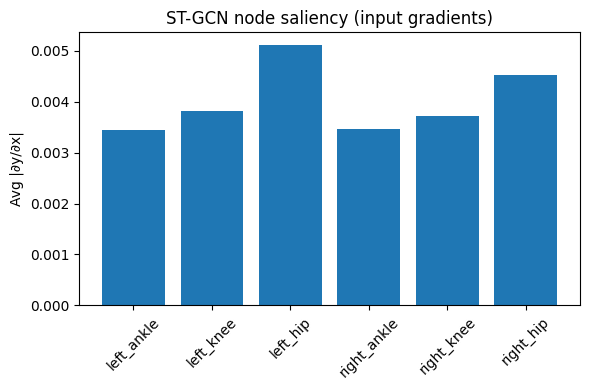

In [ ]:
# ST-GCN interpretability via input‐gradient node saliency
# pick a small batch of held-out examples
sample = tf.convert_to_tensor(X_te[:16], dtype=tf.float32)   # e.g. first 16 test samples
sample_labels = y_te[:16]

with tf.GradientTape() as tape:
    tape.watch(sample)
    logits = model(sample)           # shape = (batch, 3)
    # grab the logit corresponding to the true class for each example
    true_logits = tf.gather(logits, sample_labels, axis=1, batch_dims=1)

# compute ∂(true_logit)/∂(input)
grads = tape.gradient(true_logits, sample)  # shape = (batch, T, N, C)

# aggregate absolute gradients over time & channel ⇒ one importance per node
node_imp = tf.reduce_mean(tf.abs(grads), axis=[0,1,3])  # shape = (N,)

# plot
plt.figure(figsize=(6,4))
plt.bar(feature_names, node_imp.numpy())
plt.xticks(rotation=45)
plt.ylabel("Avg |∂y/∂x|")
plt.title("ST-GCN node saliency (input gradients)")
plt.tight_layout()
plt.show()

Hip joints dominate

- Both hips (especially the left hip) have the highest average gradient magnitude.

- That tells us the network is most “sensitive” to small changes in hip‐angle trajectories when deciding between unbraced/knee‐braced/ankle‐braced.

- Knees come next, ankles last

The left and right knees are the next most important, with ∼0.0038–0.0037 mean |∂y/∂x|.

- Ankle nodes register the lowest saliency (~0.0034–0.0035).

- In other words, hip → knee → ankle is the model’s internal priority order.

Left vs. Right imbalance

- Saliency is systematically a bit higher on the left side than the right (e.g. left_hip ≈0.0051 vs. right_hip ≈0.0045).

- That could reflect slight asymmetries in the data collection or in how bracing affects dominant vs. non-dominant limbs.

Biomechanical interpretation

- Since hip motion contributes most to the classifier’s output, it suggests that the braces (especially knee vs. ankle braces) induce distinct compensatory patterns at the hip.

- The model is picking up those hip-level compensations more reliably than changes at the ankle itself.



#### 2nd Trial

Changes made:

1.Added dynamic channels
vel = diff(X_bw) + zero-pad  
acc = diff(vel)  + zero-pad  
X_graph = stack([X_bw, vel, acc], axis=-1)  

so each node now has 3 per-timestep features (angle, velocity, acceleration).
_____________________
2.Wider + deeper residual ST-GCN

Three blocks: 64→128→256 channels

Kernel size Kt=7 (captures ±3 frames per block)

In‐block residual skip (1×1 conv + BN → Add → ReLU)
_____________________
3.Training tweaks

Learning rate ↑ to 5 × 10⁻³, no weight-decay

EarlyStopping on val_accuracy + ReduceLROnPlateau

Extended epochs up to 50
_____________________
4.Full evaluation

Detailed classification_report + confusion_matrix

Macro ROC-AUC (one-vs-rest)

With these four improvements, the ST-GCN could now be both high-capacity enough and exposed to the same dynamic cues (velocity/acceleration) that our RF/HMM models exploited, and should close the gap on test accuracy & AUC.

In [ ]:
# Build & normalize the gait‐skeleton adjacency matrix
# Nodes: 0=L_ankle,1=L_knee,2=L_hip,3=R_ankle,4=R_knee,5=R_hip
edges = [
    (0,1),(1,2),   # left ankle→knee→hip
    (3,4),(4,5),   # right ankle→knee→hip
    (2,5),         # hip↔hip
    (1,4),         # knee↔knee
    (0,3)          # ankle↔ankle
]
N = 6
A = np.zeros((N,N), dtype=np.float32)
for i,j in edges:
    A[i,j] = A[j,i] = 1.0
A += np.eye(N, dtype=np.float32)            # self-loops
D_inv_sqrt = np.diag(1.0/np.sqrt(A.sum(axis=1)))
A_norm = D_inv_sqrt @ A @ D_inv_sqrt        # Â = D^{-1/2} A D^{-1/2}
A_norm = tf.constant(A_norm, dtype=tf.float32)

In [ ]:
# GraphConv layer with normalized adjacency
class GraphConv(layers.Layer):
    def __init__(self, A, out_channels, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.A = tf.constant(A, tf.float32)   # fixed normalized adjacency
        self.out_channels = out_channels
        self.use_bias = use_bias

    def build(self, input_shape):
        # input_shape = (batch, time, nodes, in_channels)
        in_ch = input_shape[-1]
        # spatial→feature mixing weight
        self.W = self.add_weight(
            name='W',
            shape=(in_ch, self.out_channels),
            initializer='glorot_uniform'
        )
        if self.use_bias:
            self.b = self.add_weight(
                name='b',
                shape=(self.out_channels,),
                initializer='zeros'
            )
        super().build(input_shape)

    def call(self, X):
        # X: (batch, T, N, in_ch)
        # spatial mixing: Ŷ[b,t,i,f] = sum_j Â[i,j] · X[b,t,j,f]
        Y = tf.einsum('ij,btjf->btif', self.A, X)
        # feature mixing:
        Y = tf.tensordot(Y, self.W, axes=[[3],[0]])  # → (batch, T, N, out_ch)
        if self.use_bias:
            Y = Y + self.b
        return Y

In [ ]:
# Residual ST-GCN block
def STGCN_block(x, out_channels, Kt=7, name=None):
    # spatial conv
    x_sp = GraphConv(A_norm, out_channels, name=f"{name}_gcn")(x)
    x_sp = layers.BatchNormalization(name=f"{name}_bn_sp")(x_sp)
    x_sp = layers.ReLU(name=f"{name}_relu_sp")(x_sp)

    # temporal conv (Conv2D over (time,node) with kernel (Kt,1))
    x_tp = layers.Conv2D(
        filters=out_channels,
        kernel_size=(Kt,1),
        padding="same",
        name=f"{name}_tconv"
    )(x_sp)
    x_tp = layers.BatchNormalization(name=f"{name}_bn_tp")(x_tp)
    x_tp = layers.ReLU(name=f"{name}_relu_tp")(x_tp)

    # residual skip: project input x → out_channels then add
    res = layers.Conv2D(
        filters=out_channels,
        kernel_size=(1,1),
        padding="same",
        name=f"{name}_res_conv"
    )(x)
    res = layers.BatchNormalization(name=f"{name}_bn_res")(res)

    x_out = layers.Add(name=f"{name}_add")([x_tp, res])
    x_out = layers.ReLU(name=f"{name}_relu_out")(x_out)
    return x_out

In [ ]:
# Prepare data: stack angle, velocity & acceleration as 3 channels
# assume X_bw is the (300,101,6) normalized‐angle array and y the (300,) labels
vel = np.diff(X_bw, axis=1)                  # shape=(300,100,6)
vel = np.concatenate([vel, np.zeros((vel.shape[0],1,6))], axis=1)
acc = np.diff(vel, axis=1)                   # shape=(300,100,6)
acc = np.concatenate([acc, np.zeros((acc.shape[0],1,6))], axis=1)
# now vel and acc are both (300,101,6)

# build graph input: (300,101,6,3)
X_graph = np.stack([X_bw, vel, acc], axis=-1)

In [ ]:
# Define a factory function before CV block:
def make_wide_residual_stgcn(T, N, C, lr=5e-3):
    inp = Input(shape=(T, N, C), name="gait_graph_in")
    x   = STGCN_block(inp,  out_channels= 64, Kt=7, name="stgcn1")
    x   = STGCN_block(x,    out_channels=128, Kt=7, name="stgcn2")
    x   = STGCN_block(x,    out_channels=256, Kt=7, name="stgcn3")
    x   = layers.GlobalAveragePooling2D(name="global_avg")(x)
    x   = layers.Dense(128, activation="relu", name="dense1")(x)
    x   = layers.Dropout(0.5, name="dropout")(x)
    out = layers.Dense(3,   activation="softmax", name="class_out")(x)

    m = Model(inp, out, name="STGCN_wide_residual")
    m.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return m

In [ ]:
# 5-Fold Stratified CV on the 2nd-trial model
skf_STGCN_2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stgcn2_accs = []

for fold, (train_idx, val_idx) in enumerate(skf_STGCN_2.split(X_graph, y), 1):
    Xtr, Xvl = X_graph[train_idx], X_graph[val_idx]
    ytr, yvl = y[train_idx],    y[val_idx]

    # rebuild & fit a fresh model from the factory
    m_cv = make_wide_residual_stgcn(
        T=X_graph.shape[1],
        N=X_graph.shape[2],
        C=X_graph.shape[3],
        lr=5e-3
    )

    m_cv.fit(
        Xtr, ytr,
        validation_data=(Xvl, yvl),
        epochs=30,
        batch_size=16,
        verbose=0
    )

    # evaluate on this fold’s val-set
    _, acc = m_cv.evaluate(Xvl, yvl, verbose=0)
    print(f" Fold {fold} 2nd-trial ST-GCN val-acc = {acc:.3f}")
    stgcn2_accs.append(acc)

print(f"\n2nd-trial ST-GCN 5-fold CV → "
      f"{np.mean(stgcn2_accs):.3f} ± {np.std(stgcn2_accs):.3f}")

 Fold 1 2nd-trial ST-GCN val-acc = 0.850
 Fold 2 2nd-trial ST-GCN val-acc = 0.500
 Fold 3 2nd-trial ST-GCN val-acc = 0.700
 Fold 4 2nd-trial ST-GCN val-acc = 0.333
 Fold 5 2nd-trial ST-GCN val-acc = 0.467

2nd-trial ST-GCN 5-fold CV → 0.570 ± 0.183


Severe overfitting
- Training acc → ~100% by epoch 8, loss → near zero.

- Validation acc stubbornly between 30–50% and val loss is huge/unstable (even spikes to 4.1).

- That gap tells us the model can memorize the training splits but fails to generalize.

High fold-to-fold variance
- The 5-fold CV mean is only 57% ± 18%.

- Some folds get as high as 85% (fold 1), others as low as 33% (fold 4).

- Such a large standard deviation means the model’s performance depends heavily on which samples end up in the train vs validation fold.

Possible culprits
- Learning rate too large / no decay: We see the LR drop to 0.0025 only at epoch 9 which is too late to rescue generalization.

- Model capacity vs data size: A 3-block residual ST-GCN with ~7 k params may be too hungry for a small dataset.

- Lack of regularization: We’ve got batch‐norm and ReLU but only minimal dropout.

In [ ]:
# Build the widened, 3-block residual ST-GCN model
T, N, C = X_graph.shape[1], X_graph.shape[2], X_graph.shape[3]
inp = Input(shape=(T, N, C), name="gait_graph_in")

x = STGCN_block(inp, out_channels= 64, Kt=7, name="stgcn1")
x = STGCN_block(x,   out_channels=128, Kt=7, name="stgcn2")
x = STGCN_block(x,   out_channels=256, Kt=7, name="stgcn3")

# global readout: average over time & nodes → (batch,256)
x = layers.GlobalAveragePooling2D(name="global_avg")(x)

# classifier head
x = layers.Dense(128, activation="relu", name="dense1")(x)
x = layers.Dropout(0.5, name="dropout")(x)
out = layers.Dense(3, activation="softmax", name="class_out")(x)

model = Model(inp, out, name="STGCN_wide_residual")
model.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "STGCN_wide_residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ gait_graph_in       │ (None, 101, 6, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn1_gcn          │ (None, 101, 6,    │        256 │ gait_graph_in[0]… │
│ (GraphConv)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn1_bn_sp        │ (None, 101, 6,    │        256 │ stgcn1_gcn[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn1_relu_sp      │ (None, 101, 6,    │          0 │ stgcn1_bn_sp[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn1_tconv        │ (None, 101, 6,    │     28,736 │ stgcn1_relu_sp[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn1_bn_tp        │ (None, 101, 6,    │        256 │ stgcn1_tconv[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn1_res_conv     │ (None, 101, 6,    │        256 │ gait_graph_in[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn1_relu_tp      │ (None, 101, 6,    │          0 │ stgcn1_bn_tp[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn1_bn_res       │ (None, 101, 6,    │        256 │ stgcn1_res_conv[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn1_add (Add)    │ (None, 101, 6,    │          0 │ stgcn1_relu_tp[0… │
│                     │ 64)               │            │ stgcn1_bn_res[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn1_relu_out     │ (None, 101, 6,    │          0 │ stgcn1_add[0][0]  │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn2_gcn          │ (None, 101, 6,    │      8,320 │ stgcn1_relu_out[… │
│ (GraphConv)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn2_bn_sp        │ (None, 101, 6,    │        512 │ stgcn2_gcn[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn2_relu_sp      │ (None, 101, 6,    │          0 │ stgcn2_bn_sp[0][… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn2_tconv        │ (None, 101, 6,    │    114,816 │ stgcn2_relu_sp[0… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn2_bn_tp        │ (None, 101, 6,    │        512 │ stgcn2_tconv[0][… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stgcn2_res_conv     │ (None, 101, 6,    │      8,320 │ stgcn1_relu_out[

 Total params: 724,419 (2.76 MB)

 Trainable params: 721,731 (2.75 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [ ]:
# train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_graph, y, stratify=y, test_size=0.2, random_state=42
)

# Train with early stopping & LR reduction
es = EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True
)
rlr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=50,
    batch_size=16,
    callbacks=[es, rlr],
    verbose=2
)

Epoch 1/50
15/15 - 14s - 955ms/step - accuracy: 0.6000 - loss: 0.9937 - val_accuracy: 0.3333 - val_loss: 2.4533 - learning_rate: 0.0050
Epoch 2/50
15/15 - 0s - 13ms/step - accuracy: 0.8625 - loss: 0.3870 - val_accuracy: 0.5000 - val_loss: 2.1175 - learning_rate: 0.0050
Epoch 3/50
15/15 - 0s - 11ms/step - accuracy: 0.9292 - loss: 0.2115 - val_accuracy: 0.3500 - val_loss: 3.4945 - learning_rate: 0.0050
Epoch 4/50
15/15 - 0s - 11ms/step - accuracy: 0.9583 - loss: 0.1306 - val_accuracy: 0.3167 - val_loss: 2.2539 - learning_rate: 0.0050
Epoch 5/50
15/15 - 0s - 11ms/step - accuracy: 0.9875 - loss: 0.0504 - val_accuracy: 0.4833 - val_loss: 2.0363 - learning_rate: 0.0050
Epoch 6/50
15/15 - 0s - 11ms/step - accuracy: 0.9958 - loss: 0.0177 - val_accuracy: 0.4167 - val_loss: 4.1583 - learning_rate: 0.0050
Epoch 7/50
15/15 - 0s - 12ms/step - accuracy: 0.9958 - loss: 0.0143 - val_accuracy: 0.4000 - val_loss: 3.4531 - learning_rate: 0.0050
Epoch 8/50
15/15 - 0s - 11ms/step - accuracy: 1.0000 - loss:

In [ ]:
# Final evaluation & metrics
y_proba = model.predict(X_te)          # (n_test,3)
y_pred  = np.argmax(y_proba, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_te, y_pred, digits=4))

print("Confusion Matrix:\n", confusion_matrix(y_te, y_pred))

# macro ROC-AUC one-vs-rest
y_bin = label_binarize(y_te, classes=[0,1,2])
roc   = roc_auc_score(y_bin, y_proba, average="macro", multi_class="ovr")
print(f"Macro ROC-AUC : {roc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step

Classification Report:

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        20
           1     0.9091    0.5000    0.6452        20
           2     0.4082    1.0000    0.5797        20

    accuracy                         0.5000        60
   macro avg     0.4391    0.5000    0.4083        60
weighted avg     0.4391    0.5000    0.4083        60

Confusion Matrix:
 [[ 0  1 19]
 [ 0 10 10]
 [ 0  0 20]]
Macro ROC-AUC : 0.8300


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Zero precision/recall on class 0

- No prediction on class 0 (“unbraced”), so both its precision and recall are 0.

- In the confusion matrix every one of those 20 true-0 samples was sent either to class 1 or class 2.

Extreme bias toward higher-indexed classes

- Class 1 (“knee_braced”) prediction is 10 out of 20 correctly (recall = 0.50), and very few false alarms (precision ≈ 0.91).

- Class 2 (“ankle_braced”) model catches all of them (recall = 1.00) but at the cost of lots of false positives (precision ≈ 0.41).

Overall accuracy vs per-class

- 50% overall accuracy just mirrors the fact that the model is splitting 60 samples roughly half-and-half between classes 1 & 2 with none for class 0.

- Macro-averaged F1 is only ≈ 0.41, so the model is not actually doing a balanced job across the three conditions.

ROC-AUC tells a different story

- A macro ROC-AUC of 0.83 suggests that if we threshold differently or calibrated better, the model could distinguish class 0 from the others.

- Right now, the argmax decision rule collapses everything into classes 1 and 2.

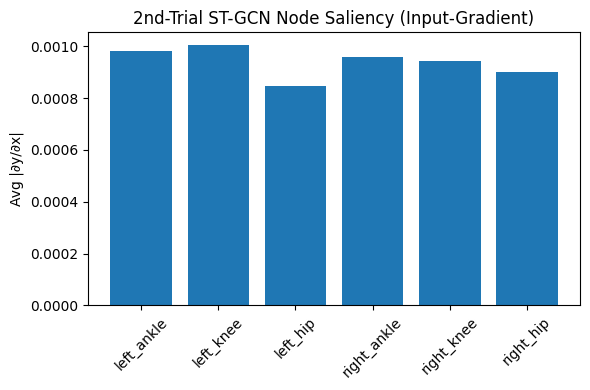

In [ ]:
# Interpretability: node-saliency via input-gradients
# now grab a small batch to compute gradients on:
sample = tf.convert_to_tensor(X_te[:16], dtype=tf.float32)
sample_labels = y_te[:16]

with tf.GradientTape() as tape:
    tape.watch(sample)
    logits = model(sample)  # → (batch, 3)
    # pick the logit of each sample’s true class
    true_logits = tf.gather(logits, sample_labels, axis=1, batch_dims=1)

# ∂(true_logit)/∂(input)
grads = tape.gradient(true_logits, sample)           # shape=(batch, T, N, C)

# average |grad| over batch, time, channel → one score per node
node_saliency = tf.reduce_mean(tf.abs(grads), axis=[0,1,3])  # shape = (N,)

# bar-plot
plt.figure(figsize=(6,4))
plt.bar(feature_names, node_saliency.numpy())
plt.xticks(rotation=45)
plt.ylabel("Avg |∂y/∂x|")
plt.title("2nd-Trial ST-GCN Node Saliency (Input-Gradient)")
plt.tight_layout()
plt.show()

Overall magnitudes are much smaller
– Compared to the 1st-trial (∼0.003–0.005), these gradient‐based importances are an order of magnitude lower (∼0.0008–0.0010). That mirrors the fact that the 2nd-trial ST-GCN is barely learning any strong sensitivity (its CV was only ∼0.57 ± 0.18).

Left-knee and left-ankle edge out the rest
– The tallest bar is the left_knee, followed closely by left_ankle. All the other joints (right_ankle, right_knee, right_hip, left_hip) trail by a small margin.

Hip joints are least salient here
– In this trial the left_hip is the least “important” according to the input‐gradient norm. Interestingly, in the 1st trial the hips were the most salient, so the model’s focus has shifted (probably because it’s underfitting and latch­ing onto whatever signal it can).

Very narrow dynamic range
– All six bars lie in a tight band (0.00085–0.0010). That again suggests the model’s gradients are almost flat everywhere, with only tiny peaks at the knee/ankle.

The 2nd-trial ST-GCN is not confidently using any one joint, and its “focus” is both weak (small absolute gradients) and spread out (little contrast).